# 03 — Análisis de Correlación Macroeconómica Avanzado

**Sistema de Análisis y Pronóstico de Rentas Cedidas** | ADRES — Colombia

---

## Objetivo

Identificar los **determinantes externos** que explican la variabilidad del
recaudo de Rentas Cedidas y validar su inclusión como regresores exógenos
en modelos **SARIMAX**.

| Fase | Análisis | Variables |
|------|----------|-----------|
| **I** | Deflación de Licores/Cigarrillos + CCF (Dic→Ene) | IPC, ENCSPA, Recaudo vertical |
| **II** | Sensibilidad de Juegos de Azar al Ingreso | SMLV, Tasa Desempleo, Elasticidad |
| **III** | UPC como Variable de Control | UPC vs Recaudo, Causalidad Granger |
| **IV** | Quiebres Estructurales (Change Points) | CUSUM, Bai-Perron, Pandemic effect |
| **V** | Matrices de Correlación + VIF | Pearson, Spearman, log-lags, VIF |
| **VI** | Conclusiones — Regresores SARIMAX | Tabla de decisión final |

> **Dependencia**: `serie_mensual.csv` (01_EDA), macro verificado (`00_config.py`).

In [1]:
import pandas as pd
import numpy as np

%run 00_config.py

# ── Paquetes estadísticos ──
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

# ── Serie mensual (01_EDA) ──
df_mensual = pd.read_csv(
    DATA_PROCESSED / 'serie_mensual.csv',
    parse_dates=['Fecha'], index_col='Fecha')
df_mensual.index.freq = 'MS'
serie = df_mensual['Recaudo_Total']

# ── Dataset crudo para verticales ──
df_raw = pd.read_excel(DATA_FILE)
df_raw[COL_FECHA] = pd.to_datetime(df_raw[COL_FECHA])
df_raw[COL_VALOR] = pd.to_numeric(df_raw[COL_VALOR], errors='coerce')

# ── Macro mensualizado ──
macro_df = pd.DataFrame(MACRO_DATA).T
macro_df.index.name = 'Año'
macro_m = pd.DataFrame(index=serie.index)
for col in macro_df.columns:
    proxy = pd.Series(dtype=float, index=serie.index)
    for yr, val in macro_df[col].items():
        proxy[serie.index.year == yr] = val
    macro_m[col] = proxy.astype(float).interpolate('linear')

# ── SMLV nominal (COP) ──
SMLV_COP = {2021: 908526, 2022: 1000000, 2023: 1160000,
             2024: 1300000, 2025: 1423500, 2026: 1750905}
macro_m['SMLV_COP'] = [SMLV_COP.get(d.year, SMLV_COP[max(SMLV_COP)])
                        for d in serie.index]

# ── IPC acumulado (índice, base oct-2021 = 100) ──
ipc_idx = pd.Series(100.0, index=serie.index)
for i in range(1, len(ipc_idx)):
    yr = ipc_idx.index[i].year
    ipc_a = MACRO_DATA.get(yr, MACRO_DATA[max(MACRO_DATA)])['IPC']
    ipc_idx.iloc[i] = ipc_idx.iloc[i-1] * (1 + ipc_a / 100 / 12)
macro_m['IPC_Idx'] = ipc_idx

# ── Tasa de desempleo proxy (DANE Gran Encuesta Integrada Hogares) ──
# Promedios anuales aprox. para Colombia
DESEMPLEO = {2021: 13.7, 2022: 11.2, 2023: 10.2, 2024: 9.8, 2025: 9.5}
proxy_d = pd.Series(dtype=float, index=serie.index)
for yr, val in DESEMPLEO.items():
    proxy_d[serie.index.year == yr] = val
macro_m['Desempleo'] = proxy_d.astype(float).interpolate('linear')

n_meses = len(serie)
print(f"✅ Datos cargados — {n_meses} meses "
      f"({serie.index.min():%Y-%m} → {serie.index.max():%Y-%m})")
print(f"   Variables macro: {list(macro_m.columns)}")
print(f"   Categorías fuente: {df_raw['NombreSubGrupoFuente'].nunique()}")

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasCedidasVF.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica


✅ Datos cargados — 51 meses (2021-10 → 2025-12)
   Variables macro: ['IPC', 'Salario_Minimo', 'UPC', 'Consumo_Hogares', 'Desempleo', 'SMLV_COP', 'IPC_Idx']
   Categorías fuente: 10


---

## Fase I — Modelación de Dinámicas de Consumo (Licores y Cigarrillos)

### Deflación de la Serie

Se compara el recaudo **nominal** vs el recaudo **real** (ajustado por IPC)
para determinar si el crecimiento observado es:

| Componente | Significado | Indicador |
|------------|-------------|-----------|
| **Orgánico** | Mayor volumen real de consumo | $\Delta Y_{real} > 0$ |
| **Inflacionario** | Solo efecto precio | $\Delta Y_{real} \leq 0$ y $\Delta Y_{nom} > 0$ |

### Correlación Cruzada (CCF)

La hipótesis central es que el **pico de enero** es la materialización
contable del consumo masivo de diciembre (lag 1-2 meses).
Referencia complementaria: **ENCSPA** (DANE — Encuesta Nacional de Consumo
de Sustancias Psicoactivas) sobre volumen de consumo de alcohol y tabaco.

Verticales identificadas (Licores/Cigarrillos):
  • Impoconsumo Cervezas y Sifones  (3,862 reg, $1170.0MM)
  • Impoconsumo Licores, Vinos, Aperitivos y Similares  (7,850 reg, $2141.0MM)
  • Componente Especifico Consumo Cigarrillos y Tabacos  (1,221 reg, $3196.4MM)
  • Ad Valorem Impuesto Consumo Cigarrillo y Tabacos  (1,817 reg, $1444.9MM)


  📊 Figura guardada: 03_licores_deflactado.png


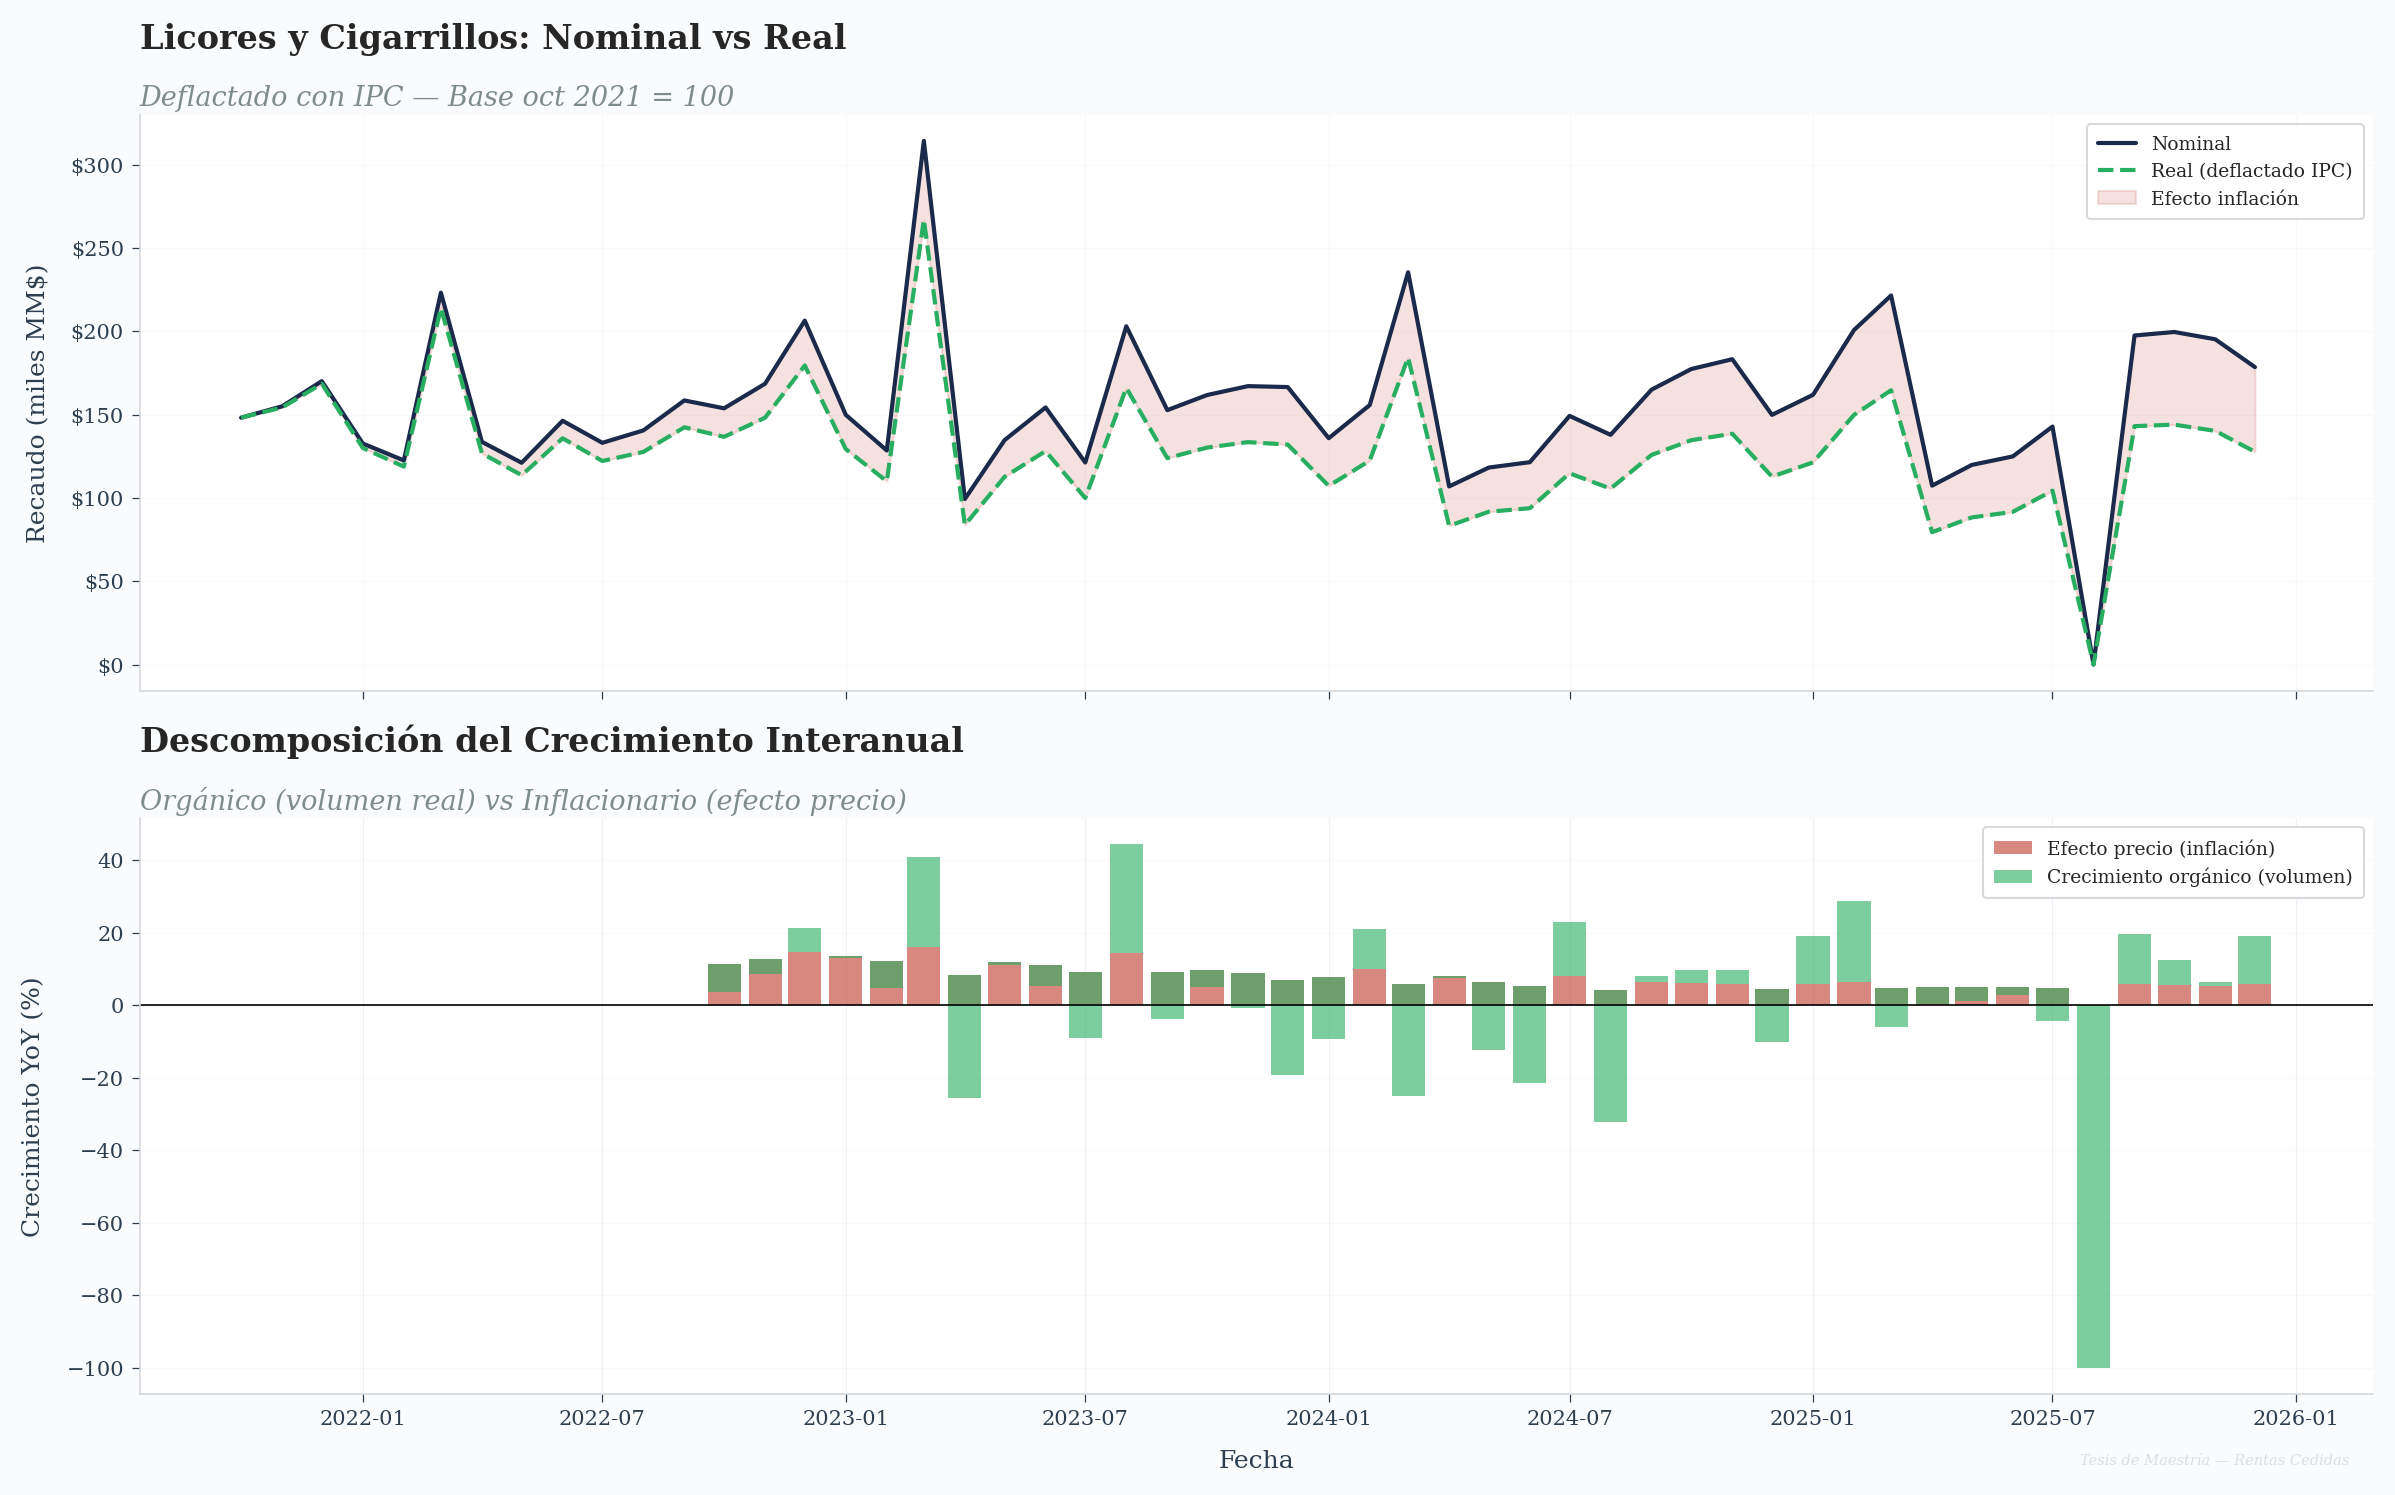


══════════════════════════════════════════════════════════════════════
DEFLACIÓN — LICORES Y CIGARRILLOS
══════════════════════════════════════════════════════════════════════
  Crec. nominal medio YoY:  +1.80%
  Crec. real medio YoY:     -6.17%
  Efecto precio medio:      +7.97%

  ⚠️ Crecimiento INFLACIONARIO — solo efecto precio
     Ref. ENCSPA: posible contracción real; recaudo sostiene
     por ajuste tarifario (indización al IPC)


In [2]:
# ══════════════════════════════════════════════════════════════
# FASE I.1 — Deflación del Recaudo de Licores y Cigarrillos
# ══════════════════════════════════════════════════════════════

# ── Identificar categorías ──
mask_lic = df_raw['NombreSubGrupoFuente'].str.contains(
    r'licor|cigarr|tabaco|cerveza|alcohol|bebida|consumo.*cigarr'
    r'|impuesto.*consumo',
    case=False, na=False)
cats_lic = df_raw.loc[mask_lic, 'NombreSubGrupoFuente'].unique()

if len(cats_lic) == 0:
    print("⚠️ No se hallaron categorías con keywords exactas — usando total")
    serie_lic = serie.copy()
    cats_lic = ['(Total como proxy)']
else:
    df_lic = df_raw[mask_lic].copy()
    serie_lic = (df_lic.groupby(pd.Grouper(key=COL_FECHA, freq='MS'))
                 [COL_VALOR].sum())

print("Verticales identificadas (Licores/Cigarrillos):")
for c in cats_lic:
    if c != '(Total como proxy)':
        n = (df_raw['NombreSubGrupoFuente'] == c).sum()
        v = df_raw.loc[df_raw['NombreSubGrupoFuente'] == c, COL_VALOR].sum()
        print(f"  • {c}  ({n:,} reg, ${v/1e9:.1f}MM)")

# ── Deflactar ──
serie_lic_real = serie_lic / ipc_idx * 100

# ── Crecimiento YoY ──
yoy_nom = serie_lic.pct_change(12) * 100
yoy_rea = serie_lic_real.pct_change(12) * 100
efecto_p = yoy_nom - yoy_rea

# ── Gráfica (2 paneles) ──
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

ax = axes[0]
ax.plot(serie_lic.index, serie_lic.values/1e9, color=C_PRIMARY,
        lw=2, label='Nominal')
ax.plot(serie_lic_real.index, serie_lic_real.values/1e9, color=C_QUATERNARY,
        lw=2, ls='--', label='Real (deflactado IPC)')
ax.fill_between(serie_lic.index,
                serie_lic_real.values/1e9, serie_lic.values/1e9,
                alpha=0.15, color=C_SECONDARY, label='Efecto inflación')
ax.set_ylabel('Recaudo (miles MM$)', fontdict=FONT_AXIS)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Licores y Cigarrillos: Nominal vs Real',
                       'Deflactado con IPC — Base oct 2021 = 100')
    formato_pesos_eje(ax, eje='y')

ax = axes[1]
vld = ~yoy_nom.isna()
ax.bar(yoy_nom.index[vld], efecto_p.values[vld], width=25,
       color=C_SECONDARY, alpha=0.6, label='Efecto precio (inflación)')
ax.bar(yoy_nom.index[vld], yoy_rea.values[vld], width=25,
       color=C_QUATERNARY, alpha=0.6, bottom=efecto_p.values[vld],
       label='Crecimiento orgánico (volumen)')
ax.axhline(y=0, color='black', lw=0.8)
ax.set_ylabel('Crecimiento YoY (%)', fontdict=FONT_AXIS)
ax.set_xlabel('Fecha', fontdict=FONT_AXIS)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Descomposición del Crecimiento Interanual',
                       'Orgánico (volumen real) vs Inflacionario (efecto precio)')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '03_licores_deflactado', OUTPUTS_FIGURES)
plt.show()

# ── Reporte ──
if vld.sum() > 0:
    cn = yoy_nom[vld].mean(); cr = yoy_rea[vld].mean(); ep = efecto_p[vld].mean()
    print(f"\n{'═'*70}")
    print(f"DEFLACIÓN — LICORES Y CIGARRILLOS")
    print(f"{'═'*70}")
    print(f"  Crec. nominal medio YoY:  {cn:+.2f}%")
    print(f"  Crec. real medio YoY:     {cr:+.2f}%")
    print(f"  Efecto precio medio:      {ep:+.2f}%")
    if cr > 0:
        print(f"\n  ✅ Crecimiento ORGÁNICO positivo — volumen real aumenta")
        print(f"     Referencia ENCSPA (DANE): tendencia de consumo creciente")
    else:
        print(f"\n  ⚠️ Crecimiento INFLACIONARIO — solo efecto precio")
        print(f"     Ref. ENCSPA: posible contracción real; recaudo sostiene")
        print(f"     por ajuste tarifario (indización al IPC)")

  📊 Figura guardada: 03_ccf_dic_ene.png


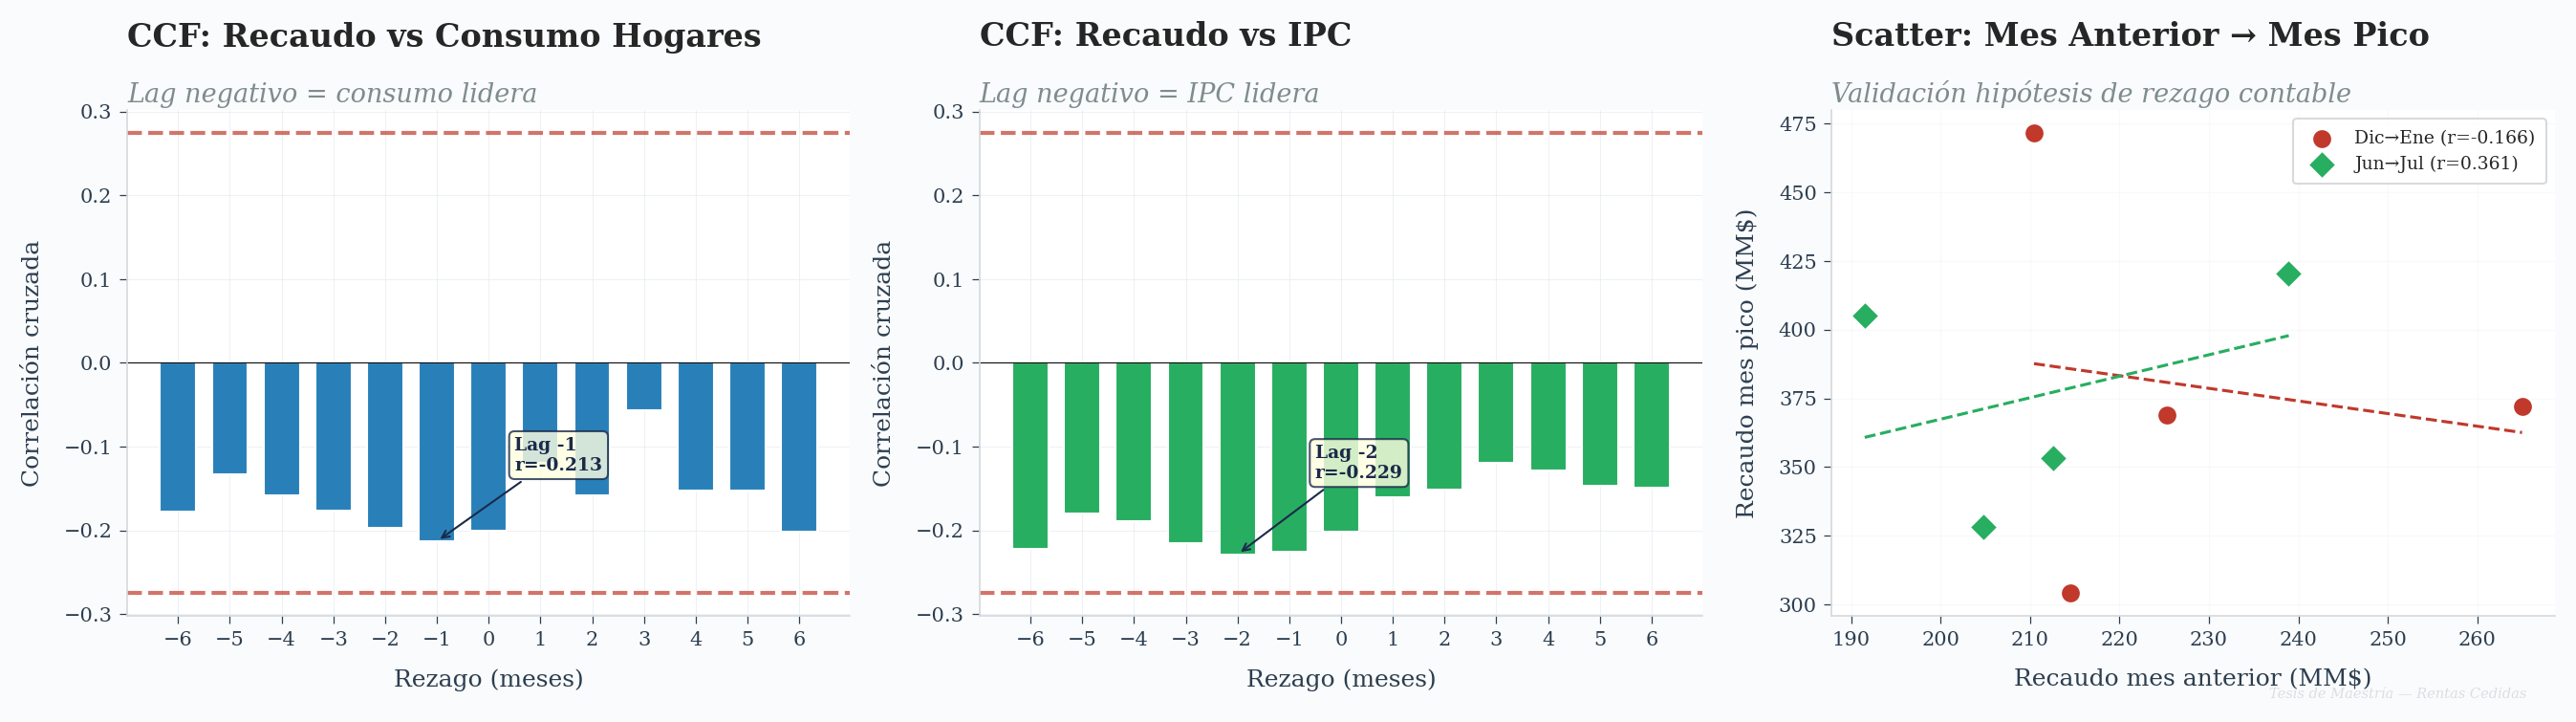


══════════════════════════════════════════════════════════════════════
VALIDACIÓN DE HIPÓTESIS — REZAGO CONTABLE
══════════════════════════════════════════════════════════════════════
  CCF Consumo→Recaudo:  Lag = -1 (r = -0.2132)
  CCF IPC→Recaudo:      Lag = -2 (r = -0.2288)
  IC 95% (Bartlett):    ±0.2745

  Correlación Dic → Ene:  r = -0.1658  (p = 0.8342)
  Correlación Jun → Jul:  r = 0.3605  (p = 0.6395)

  ⚠️ HIPÓTESIS NO CONCLUYENTE: lag-1 Dic→Ene r=-0.166
     Estacionalidad pura (lag-12) puede dominar


In [3]:
# ══════════════════════════════════════════════════════════════
# FASE I.2 — Correlación Cruzada (CCF): Validación Dic → Ene
# ══════════════════════════════════════════════════════════════

# ── CCF manual ──
max_lag = 6

def ccf_manual(x, y, max_lags):
    n = len(x)
    r = []
    for lag in range(-max_lags, max_lags + 1):
        if lag >= 0:
            c = np.corrcoef(x[lag:], y[:n-lag])[0,1] if n-lag > 2 else 0
        else:
            c = np.corrcoef(x[:n+lag], y[-lag:])[0,1] if n+lag > 2 else 0
        r.append(c)
    return r

serie_norm = (serie - serie.mean()) / serie.std()

# ── CCF entre consumo proxy y recaudo ──
consumo_norm = ((macro_m['Consumo_Hogares'] - macro_m['Consumo_Hogares'].mean())
                / macro_m['Consumo_Hogares'].std())
ipc_norm = ((macro_m['IPC'] - macro_m['IPC'].mean())
            / macro_m['IPC'].std())

lags = list(range(-max_lag, max_lag + 1))
ccf_cons = ccf_manual(serie_norm.values, consumo_norm.values, max_lag)
ccf_ipc  = ccf_manual(serie_norm.values, ipc_norm.values, max_lag)

ci_95 = 1.96 / np.sqrt(len(serie))

# ── Autocorrelación específica: ¿Enero depende de Diciembre? ──
# Construir pares (dic, ene+1)
pares_dic_ene = []
for yr in sorted(serie.index.year.unique()):
    dic = serie.get(pd.Timestamp(f'{yr}-12-01'), np.nan)
    ene = serie.get(pd.Timestamp(f'{yr+1}-01-01'), np.nan)
    if not np.isnan(dic) and not np.isnan(ene):
        pares_dic_ene.append((dic, ene))

if len(pares_dic_ene) >= 3:
    arr = np.array(pares_dic_ene)
    r_dic_ene, p_dic_ene = stats.pearsonr(arr[:,0], arr[:,1])
else:
    r_dic_ene = p_dic_ene = np.nan

# ── Pares Jun → Jul ──
pares_jun_jul = []
for yr in sorted(serie.index.year.unique()):
    jun = serie.get(pd.Timestamp(f'{yr}-06-01'), np.nan)
    jul = serie.get(pd.Timestamp(f'{yr}-07-01'), np.nan)
    if not np.isnan(jun) and not np.isnan(jul):
        pares_jun_jul.append((jun, jul))

if len(pares_jun_jul) >= 3:
    arr2 = np.array(pares_jun_jul)
    r_jun_jul, p_jun_jul = stats.pearsonr(arr2[:,0], arr2[:,1])
else:
    r_jun_jul = p_jun_jul = np.nan

# ── Gráfica CCF ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, vals, tit, col, sub in [
    (axes[0], ccf_cons, 'CCF: Recaudo vs Consumo Hogares',
     C_TERTIARY, 'Lag negativo = consumo lidera'),
    (axes[1], ccf_ipc, 'CCF: Recaudo vs IPC',
     C_QUATERNARY, 'Lag negativo = IPC lidera'),
]:
    colores_bar = [C_SECONDARY if abs(v)>ci_95 else col for v in vals]
    ax.bar(lags, vals, color=colores_bar, edgecolor='white', width=0.7)
    ax.axhline(y= ci_95, color=C_SECONDARY, ls='--', alpha=0.7)
    ax.axhline(y=-ci_95, color=C_SECONDARY, ls='--', alpha=0.7)
    ax.axhline(y=0, color='black', lw=0.5)
    ax.set_xlabel('Rezago (meses)', fontdict=FONT_AXIS)
    ax.set_ylabel('Correlación cruzada', fontdict=FONT_AXIS)
    ax.set_xticks(lags)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, tit, sub)
    idx_opt = int(np.argmax(np.abs(vals)))
    ax.annotate(f'Lag {lags[idx_opt]:+d}\nr={vals[idx_opt]:.3f}',
                xy=(lags[idx_opt], vals[idx_opt]),
                xytext=(lags[idx_opt]+1.5, vals[idx_opt]*0.6),
                arrowprops=dict(arrowstyle='->', color=C_PRIMARY),
                fontsize=9, fontweight='bold', color=C_PRIMARY,
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='lightyellow', edgecolor=C_PRIMARY, alpha=0.8))

# Panel 3: Scatter Dic→Ene / Jun→Jul
ax = axes[2]
if len(pares_dic_ene) >= 3:
    ax.scatter(arr[:,0]/1e9, arr[:,1]/1e9, color=C_SECONDARY, s=100,
               zorder=5, edgecolors='white', label=f'Dic→Ene (r={r_dic_ene:.3f})')
    z1 = np.polyfit(arr[:,0]/1e9, arr[:,1]/1e9, 1)
    xl = np.linspace(arr[:,0].min()/1e9, arr[:,0].max()/1e9, 50)
    ax.plot(xl, np.polyval(z1, xl), '--', color=C_SECONDARY, lw=1.5)
if len(pares_jun_jul) >= 3:
    ax.scatter(arr2[:,0]/1e9, arr2[:,1]/1e9, color=C_QUATERNARY, s=100,
               zorder=5, edgecolors='white', marker='D',
               label=f'Jun→Jul (r={r_jun_jul:.3f})')
    z2 = np.polyfit(arr2[:,0]/1e9, arr2[:,1]/1e9, 1)
    xl2 = np.linspace(arr2[:,0].min()/1e9, arr2[:,0].max()/1e9, 50)
    ax.plot(xl2, np.polyval(z2, xl2), '--', color=C_QUATERNARY, lw=1.5)
ax.set_xlabel('Recaudo mes anterior (MM$)', fontdict=FONT_AXIS)
ax.set_ylabel('Recaudo mes pico (MM$)', fontdict=FONT_AXIS)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Scatter: Mes Anterior → Mes Pico',
                       'Validación hipótesis de rezago contable')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '03_ccf_dic_ene', OUTPUTS_FIGURES)
plt.show()

# ── Reporte ──
print(f"\n{'═'*70}")
print(f"VALIDACIÓN DE HIPÓTESIS — REZAGO CONTABLE")
print(f"{'═'*70}")
idx_c = int(np.argmax(np.abs(ccf_cons)))
idx_i = int(np.argmax(np.abs(ccf_ipc)))
print(f"  CCF Consumo→Recaudo:  Lag = {lags[idx_c]:+d} (r = {ccf_cons[idx_c]:.4f})")
print(f"  CCF IPC→Recaudo:      Lag = {lags[idx_i]:+d} (r = {ccf_ipc[idx_i]:.4f})")
print(f"  IC 95% (Bartlett):    ±{ci_95:.4f}")
print()
print(f"  Correlación Dic → Ene:  r = {r_dic_ene:.4f}  (p = {p_dic_ene:.4f})")
print(f"  Correlación Jun → Jul:  r = {r_jun_jul:.4f}  (p = {p_jun_jul:.4f})")
if not np.isnan(r_dic_ene):
    if r_dic_ene > 0.3 and p_dic_ene < 0.1:
        print(f"\n  ✅ HIPÓTESIS CONFIRMADA: Ene es materialización contable de Dic")
        print(f"     Efecto lag-1 significativo para SARIMAX")
    else:
        print(f"\n  ⚠️ HIPÓTESIS NO CONCLUYENTE: lag-1 Dic→Ene r={r_dic_ene:.3f}")
        print(f"     Estacionalidad pura (lag-12) puede dominar")

---

## Fase II — Análisis de Sensibilidad en Apuestas y Azar

### Variables Exógenas

| Variable | Fuente | Unidad |
|----------|--------|--------|
| Recaudo Juegos de Azar | Coljuegos / Rentas Cedidas | COP mensual |
| Salario Mínimo (SMLV) | Decretos presidenciales | COP nominal |
| Tasa de Desempleo | DANE — GEIH | % trimestral |

### Elasticidad Ingreso

Se estima $\beta$ por regresión log-log:

$$\ln(\text{Recaudo}_{azar}) = \alpha + \beta \ln(\text{SMLV}) + \varepsilon$$

- $|\beta| < 1$ : **Inelástico** — gasto no responde al ingreso
- $|\beta| > 1$ : **Elástico** — gasto responde al ingreso
- $\beta < 0$  : **Contra-cíclico** — paradoja del azar

Verticales de Azar identificadas:
  • Monopolio de Juegos de Suerte y Azar Entidades Territoriales  (29,722 reg)
  • COLJUEGOS para Régimen Subsidiado  (77,781 reg)


  📊 Figura guardada: 03_azar_elasticidad.png


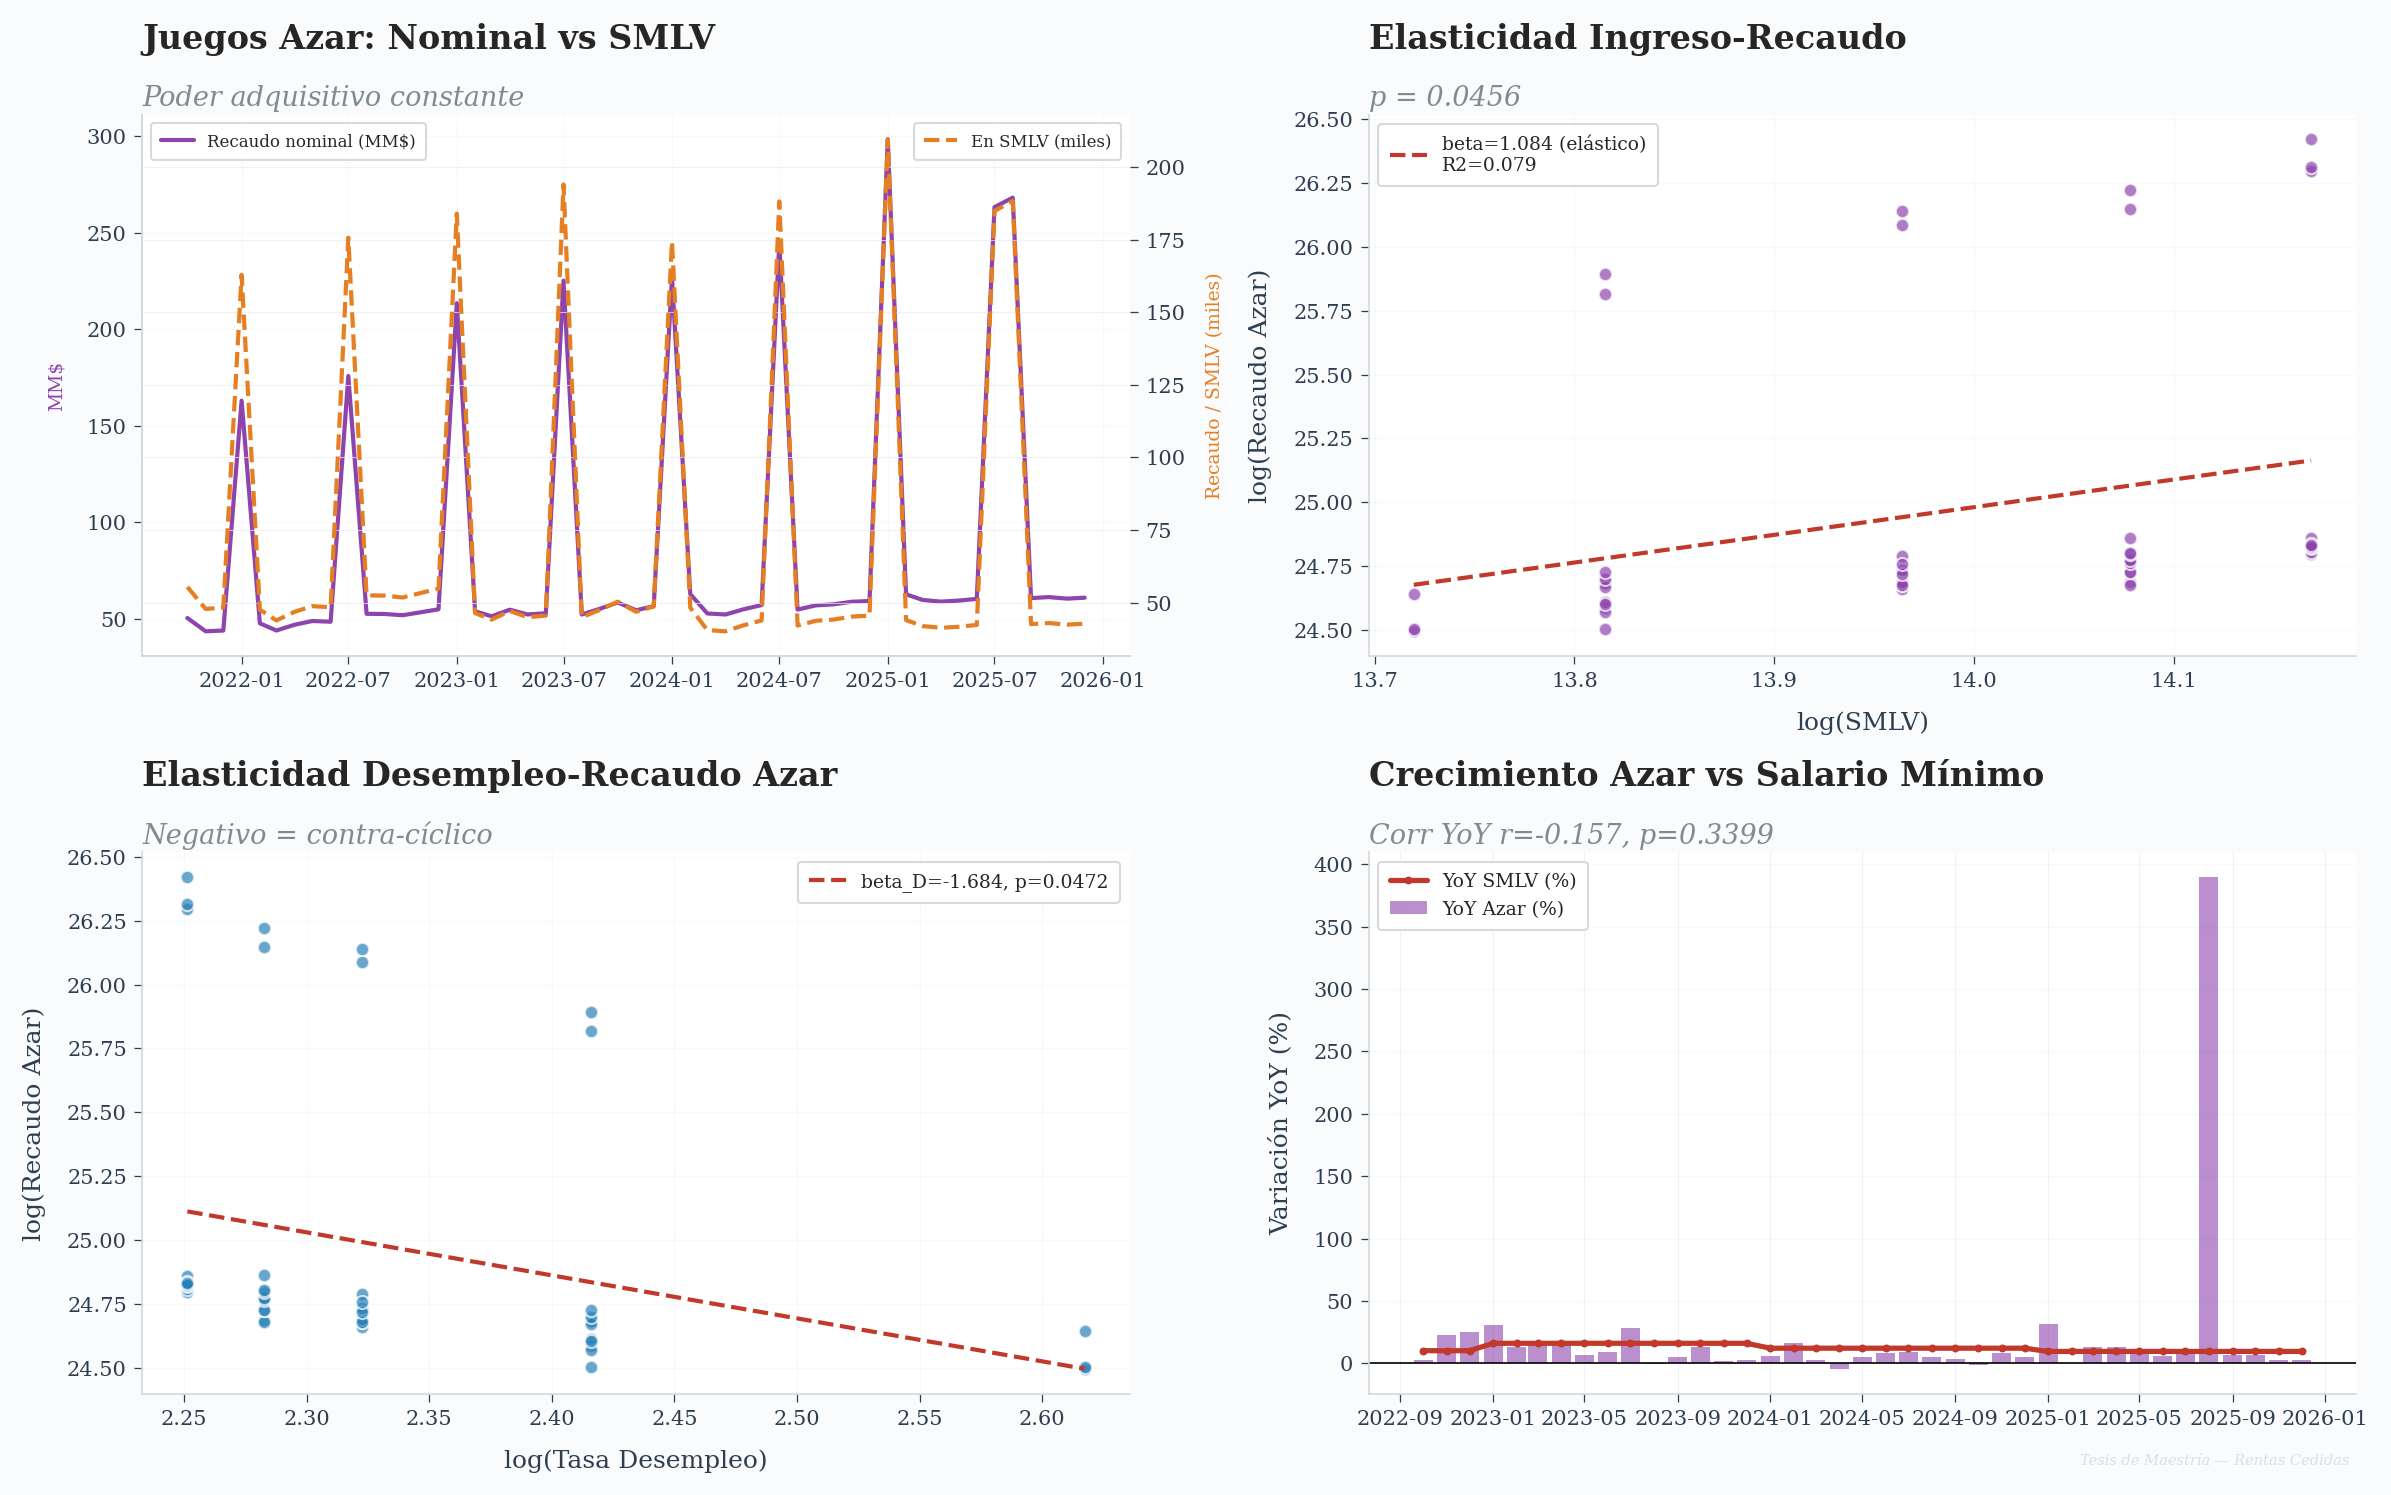


══════════════════════════════════════════════════════════════════════
JUEGOS DE AZAR — ELASTICIDAD Y COMPORTAMIENTO CÍCLICO
══════════════════════════════════════════════════════════════════════
  Elasticidad ingreso (SMLV):     beta = 1.0842  (ELÁSTICO)
  R²:                              0.0791
  p-valor:                         0.0456

  Elasticidad desempleo:           beta_D = -1.6836
  p-valor desempleo:               0.0472
     → Desempleo ↑ → Recaudo azar ↓  (pro-cíclico)

  Correlación YoY (azar vs SMLV):  r = -0.1570  (p = 0.3399)
     → Relación débil: azar relativamente INDEPENDIENTE del ingreso


In [4]:
# ══════════════════════════════════════════════════════════════
# FASE II — Sensibilidad del Recaudo de Juegos de Azar
# ══════════════════════════════════════════════════════════════

mask_azar = df_raw['NombreSubGrupoFuente'].str.contains(
    r'juego|azar|apuesta|loter|chance|suerte',
    case=False, na=False)
cats_azar = df_raw.loc[mask_azar, 'NombreSubGrupoFuente'].unique()

if len(cats_azar) == 0:
    print("⚠️ Sin categorías de azar — usando total como proxy")
    serie_azar = serie.copy()
else:
    print("Verticales de Azar identificadas:")
    for c in cats_azar:
        n = (df_raw['NombreSubGrupoFuente'] == c).sum()
        print(f"  • {c}  ({n:,} reg)")
    serie_azar = (df_raw[mask_azar]
                  .groupby(pd.Grouper(key=COL_FECHA, freq='MS'))[COL_VALOR]
                  .sum())

smlv_m = pd.Series([SMLV_COP.get(d.year, SMLV_COP[max(SMLV_COP)])
                     for d in serie_azar.index],
                    index=serie_azar.index, dtype=float)
desempleo_m = macro_m['Desempleo'].reindex(serie_azar.index).ffill()

# ── Elasticidad log-log ──
pos = serie_azar > 0
elasticidad = np.nan; r2_el = np.nan; p_el = np.nan
if pos.sum() > 12:
    log_r = np.log(serie_azar[pos])
    log_s = np.log(smlv_m[pos])
    slope, intercept, rv, p_el, se = stats.linregress(log_s.values, log_r.values)
    elasticidad = slope; r2_el = rv**2

# ── Elasticidad cruzada (desempleo) ──
elasticidad_d = np.nan; p_d = np.nan
if pos.sum() > 12:
    log_d = np.log(desempleo_m[pos])
    sl_d, _, rv_d, p_d, _ = stats.linregress(log_d.values, log_r.values)
    elasticidad_d = sl_d

# ── Recaudo en unidades SMLV ──
serie_azar_smlv = serie_azar / smlv_m

# ── PRO-CÍCLICO? (correlación YoY recaudo vs YoY SMLV) ──
yoy_az = serie_azar.pct_change(12) * 100
yoy_sm = smlv_m.pct_change(12) * 100
vld2 = ~yoy_az.isna() & ~yoy_sm.isna()
if vld2.sum() > 5:
    r_pro, p_pro = stats.pearsonr(yoy_az[vld2], yoy_sm[vld2])
else:
    r_pro = p_pro = np.nan

# ── Gráfica (2×2) ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Nominal vs SMLV
ax = axes[0, 0]
ax.plot(serie_azar.index, serie_azar.values/1e9, color=C_SENARY,
        lw=2, label='Recaudo nominal (MM$)')
ax_r = ax.twinx()
ax_r.plot(serie_azar_smlv.index, serie_azar_smlv.values/1e3,
          color=C_QUINARY, lw=2, ls='--', label='En SMLV (miles)')
ax_r.set_ylabel('Recaudo / SMLV (miles)', fontsize=9, color=C_QUINARY)
ax.set_ylabel('MM$', fontsize=9, color=C_SENARY)
ax.legend(loc='upper left', fontsize=8)
ax_r.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Juegos Azar: Nominal vs SMLV',
                       'Poder adquisitivo constante')

# Panel 2: Scatter elasticidad SMLV
ax = axes[0, 1]
if pos.sum() > 12:
    ax.scatter(log_s.values, log_r.values, color=C_SENARY, s=40,
               alpha=0.7, edgecolors='white')
    x_f = np.linspace(log_s.min(), log_s.max(), 50)
    lbl = 'inelástico' if abs(elasticidad)<1 else 'elástico'
    ax.plot(x_f, intercept + slope*x_f, '--', color=C_SECONDARY, lw=2,
            label=f'beta={elasticidad:.3f} ({lbl})\nR2={r2_el:.3f}')
    ax.set_xlabel('log(SMLV)', fontdict=FONT_AXIS)
    ax.set_ylabel('log(Recaudo Azar)', fontdict=FONT_AXIS)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'Elasticidad Ingreso-Recaudo',
                           f'p = {p_el:.4f}')

# Panel 3: Scatter elasticidad Desempleo
ax = axes[1, 0]
if pos.sum() > 12:
    ax.scatter(log_d.values, log_r.values, color=C_TERTIARY, s=40,
               alpha=0.7, edgecolors='white')
    x_d = np.linspace(log_d.min(), log_d.max(), 50)
    ax.plot(x_d, sl_d*x_d + (log_r.mean() - sl_d*log_d.mean()),
            '--', color=C_SECONDARY, lw=2,
            label=f'beta_D={elasticidad_d:.3f}, p={p_d:.4f}')
    ax.set_xlabel('log(Tasa Desempleo)', fontdict=FONT_AXIS)
    ax.set_ylabel('log(Recaudo Azar)', fontdict=FONT_AXIS)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'Elasticidad Desempleo-Recaudo Azar',
                           'Negativo = contra-cíclico')

# Panel 4: YoY azar vs YoY SMLV
ax = axes[1, 1]
if vld2.sum() > 0:
    ax.bar(yoy_az.index[vld2], yoy_az.values[vld2], width=25,
           color=C_SENARY, alpha=0.6, label='YoY Azar (%)')
    ax.plot(yoy_sm.index[vld2], yoy_sm.values[vld2], color=C_SECONDARY,
            lw=2.5, marker='o', ms=3, label='YoY SMLV (%)')
    ax.axhline(y=0, color='black', lw=0.8)
    ax.set_ylabel('Variación YoY (%)', fontdict=FONT_AXIS)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'Crecimiento Azar vs Salario Mínimo',
                           f'Corr YoY r={r_pro:.3f}, p={p_pro:.4f}'
                           if not np.isnan(r_pro) else '')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '03_azar_elasticidad', OUTPUTS_FIGURES)
plt.show()

# ── Reporte ──
print(f"\n{'═'*70}")
print(f"JUEGOS DE AZAR — ELASTICIDAD Y COMPORTAMIENTO CÍCLICO")
print(f"{'═'*70}")
if not np.isnan(elasticidad):
    print(f"  Elasticidad ingreso (SMLV):     beta = {elasticidad:.4f}  "
          f"({'INELÁSTICO' if abs(elasticidad)<1 else 'ELÁSTICO'})")
    print(f"  R²:                              {r2_el:.4f}")
    print(f"  p-valor:                         {p_el:.4f}")
if not np.isnan(elasticidad_d):
    print(f"\n  Elasticidad desempleo:           beta_D = {elasticidad_d:.4f}")
    print(f"  p-valor desempleo:               {p_d:.4f}")
    if elasticidad_d < 0:
        print(f"     → Desempleo ↑ → Recaudo azar ↓  (pro-cíclico)")
    else:
        print(f"     → Desempleo ↑ → Recaudo azar ↑  (contra-cíclico / refugio)")
if not np.isnan(r_pro):
    print(f"\n  Correlación YoY (azar vs SMLV):  r = {r_pro:.4f}  (p = {p_pro:.4f})")
    if r_pro > 0.3:
        print(f"     → PRO-CÍCLICO: azar acompaña al ingreso")
    elif r_pro < -0.3:
        print(f"     → CONTRA-CÍCLICO: paradoja del azar")
    else:
        print(f"     → Relación débil: azar relativamente INDEPENDIENTE del ingreso")

---

## Fase III — Evaluación de la UPC como Variable de Control

### Controversia Técnica

La **Unidad de Pago por Capitación (UPC)** determina cuánto recibe cada EPS por
afiliado para servicios de salud. La hipótesis nula es:

> $H_0$: *La UPC no causa (en sentido de Granger) el recaudo de Rentas Cedidas;
> su impacto se limita al gasto.*

Se evalúa mediante:
1. **Test de Causalidad de Granger** (p < 0.05 → rechazar $H_0$)
2. **Correlación parcial** (controlando IPC y SMLV)
3. **IEP** — Índice de Eficiencia Predictiva = $\frac{\Delta\% \text{Recaudo}}{\Delta\% \text{UPC}}$
   - $IEP > 1$ : Superávit fiscal (recaudo crece más que UPC)
   - $IEP < 1$ : Alerta Roja — brecha de sostenibilidad

  📊 Figura guardada: 03_upc_sostenibilidad.png


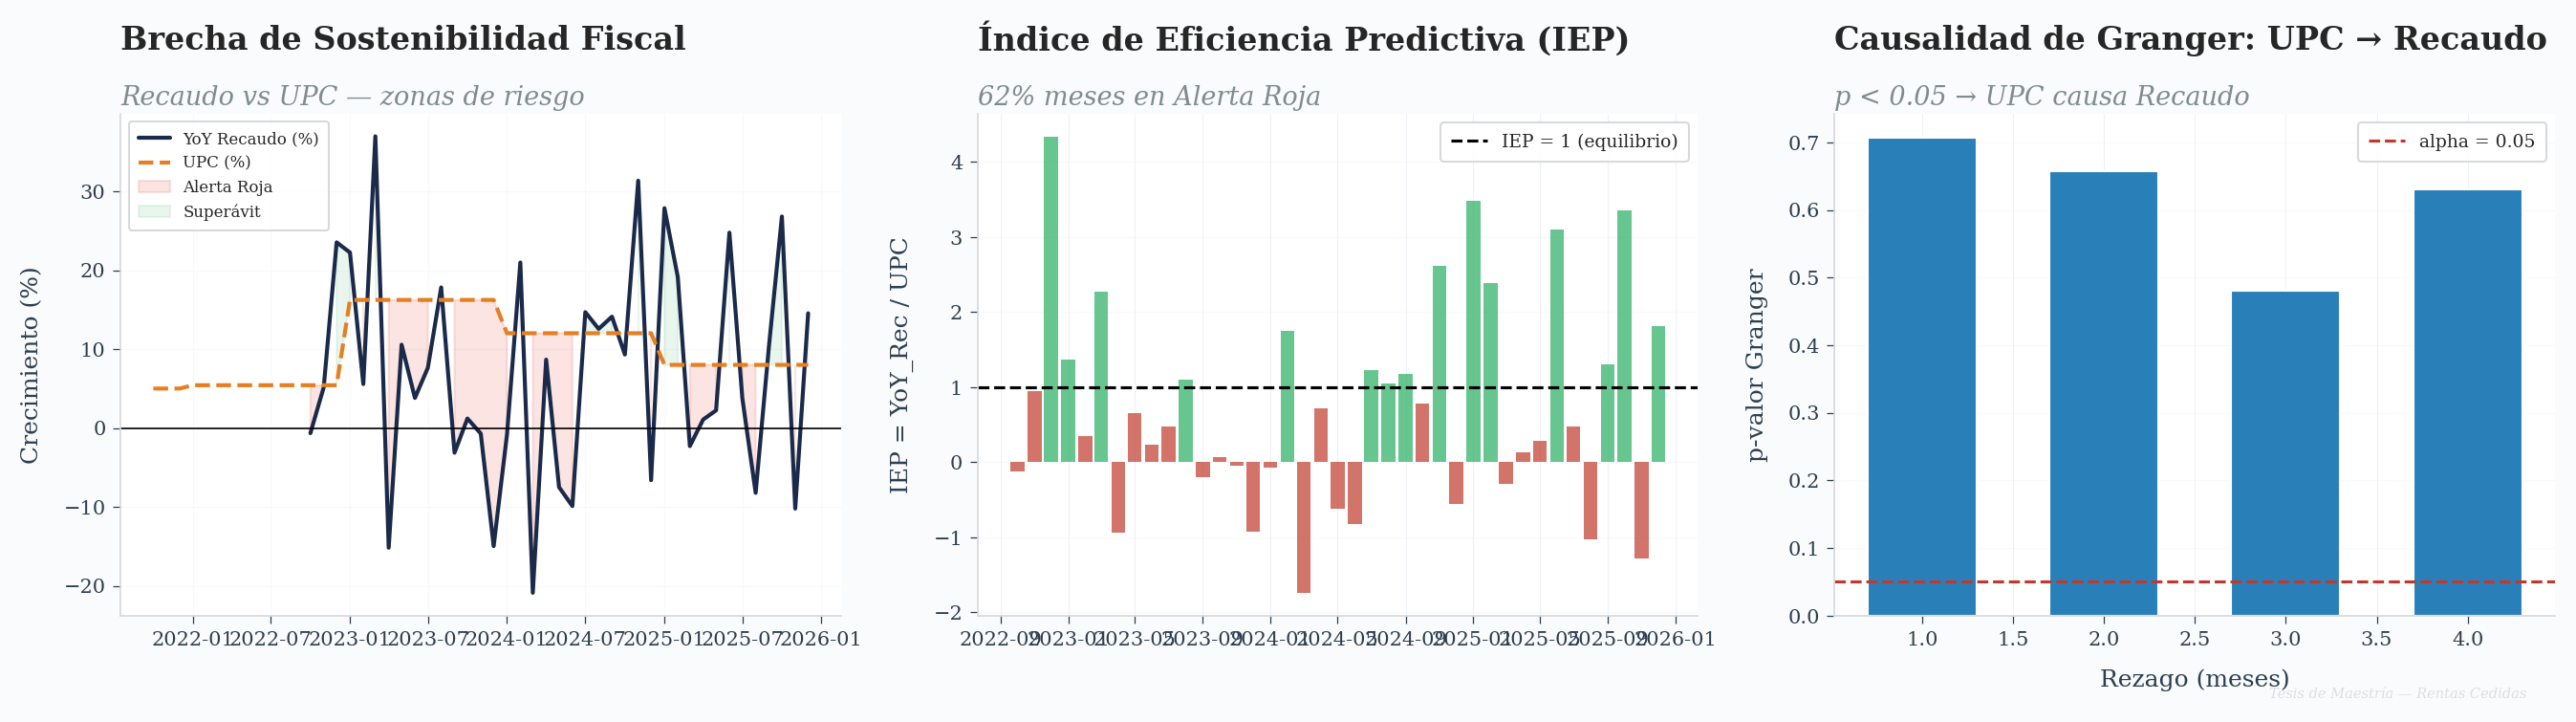


══════════════════════════════════════════════════════════════════════
UPC — EVALUACIÓN COMO VARIABLE DE CONTROL
══════════════════════════════════════════════════════════════════════
  Granger lag 1:  p = 0.7072  (✗ No significativo)
  Granger lag 2:  p = 0.6571  (✗ No significativo)
  Granger lag 3:  p = 0.4811  (✗ No significativo)
  Granger lag 4:  p = 0.6297  (✗ No significativo)

  Correlación parcial (ctrl IPC, SMLV): r = -0.1747  (p = 0.2200)

  IEP < 1 (Alerta Roja):  62% de los meses
  IEP medio:              0.74

  ✅ UPC NO es determinante directo del recaudo
     Impacta exclusivamente el GASTO — confirma hipótesis
     → NO incluir en SARIMAX (evitar ruido)


In [5]:
# ══════════════════════════════════════════════════════════════
# FASE III — UPC: ¿Variable de Control o Ruido?
# ══════════════════════════════════════════════════════════════

# ── Serie YoY recaudo + UPC ──
yoy_rec = serie.pct_change(12) * 100
upc_m   = macro_m['UPC'].copy()

# ── Test de Granger (lag 1–4) ──
df_granger = pd.DataFrame({
    'Recaudo': serie.values, 'UPC': upc_m.values}).dropna()

granger_res = {}
try:
    gc = grangercausalitytests(df_granger[['Recaudo','UPC']], maxlag=4,
                               verbose=False)
    for lag in range(1, 5):
        p_ssr = gc[lag][0]['ssr_ftest'][1]
        granger_res[lag] = p_ssr
except Exception as e:
    print(f"  ⚠️ Granger falló: {e}")

# ── IEP = YoY_Recaudo / UPC ──
vld_iep = ~yoy_rec.isna() & (upc_m != 0)
iep = yoy_rec[vld_iep] / upc_m[vld_iep]

# ── Correlación parcial (controlando IPC y SMLV) ──
# Método: regresión residual
from numpy.linalg import lstsq
df_partial = pd.DataFrame({
    'R': serie.values,
    'UPC': upc_m.values,
    'IPC': macro_m['IPC'].values,
    'SMLV': macro_m['Salario_Minimo'].values}).dropna()

if len(df_partial) > 10:
    X_ctrl = df_partial[['IPC','SMLV']].values
    X_ctrl = np.column_stack([np.ones(len(X_ctrl)), X_ctrl])
    res_r, _, _, _ = lstsq(X_ctrl, df_partial['R'].values, rcond=None)
    res_u, _, _, _ = lstsq(X_ctrl, df_partial['UPC'].values, rcond=None)
    e_r = df_partial['R'].values - X_ctrl @ res_r
    e_u = df_partial['UPC'].values - X_ctrl @ res_u
    r_partial, p_partial = stats.pearsonr(e_r, e_u)
else:
    r_partial = p_partial = np.nan

# ── Gráfica (3 paneles) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Brecha YoY vs UPC (riesgo fiscal)
ax = axes[0]
vld3 = ~yoy_rec.isna()
ax.plot(yoy_rec.index[vld3], yoy_rec.values[vld3], color=C_PRIMARY,
        lw=2, label='YoY Recaudo (%)')
ax.plot(upc_m.index, upc_m.values, color=C_QUINARY, lw=2, ls='--',
        label='UPC (%)')
ax.fill_between(yoy_rec.index[vld3], yoy_rec.values[vld3], upc_m.values[vld3],
                where=(upc_m.values[vld3] > yoy_rec.values[vld3]),
                color=C_NEGATIVE, alpha=0.15, label='Alerta Roja')
ax.fill_between(yoy_rec.index[vld3], yoy_rec.values[vld3], upc_m.values[vld3],
                where=(yoy_rec.values[vld3] >= upc_m.values[vld3]),
                color=C_POSITIVE, alpha=0.1, label='Superávit')
ax.axhline(y=0, color='black', lw=0.8)
ax.set_ylabel('Crecimiento (%)', fontdict=FONT_AXIS)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Brecha de Sostenibilidad Fiscal',
                       'Recaudo vs UPC — zonas de riesgo')

# Panel 2: IEP timeline
ax = axes[1]
if vld_iep.sum() > 0:
    colores_iep = ['#C0392B' if v < 1 else '#27AE60' for v in iep.values]
    ax.bar(iep.index, iep.values, width=25, color=colores_iep, alpha=0.7)
    ax.axhline(y=1, color='black', lw=1.5, ls='--',
               label='IEP = 1 (equilibrio)')
    ax.set_ylabel('IEP = YoY_Rec / UPC', fontdict=FONT_AXIS)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
    pct_alerta = (iep < 1).sum() / len(iep) * 100
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'Índice de Eficiencia Predictiva (IEP)',
                           f'{pct_alerta:.0f}% meses en Alerta Roja')

# Panel 3: Granger p-values
ax = axes[2]
if granger_res:
    lags_g = list(granger_res.keys())
    pvals  = list(granger_res.values())
    colores_g = [C_SECONDARY if p < 0.05 else C_TERTIARY for p in pvals]
    ax.bar(lags_g, pvals, color=colores_g, edgecolor='white', width=0.6)
    ax.axhline(y=0.05, color=C_SECONDARY, ls='--', lw=1.5,
               label='alpha = 0.05')
    ax.set_xlabel('Rezago (meses)', fontdict=FONT_AXIS)
    ax.set_ylabel('p-valor Granger', fontdict=FONT_AXIS)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'Causalidad de Granger: UPC → Recaudo',
                           'p < 0.05 → UPC causa Recaudo')
else:
    ax.text(0.5, 0.5, 'Granger no disponible', ha='center',
            va='center', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '03_upc_sostenibilidad', OUTPUTS_FIGURES)
plt.show()

# ── Reporte ──
print(f"\n{'═'*70}")
print(f"UPC — EVALUACIÓN COMO VARIABLE DE CONTROL")
print(f"{'═'*70}")
if granger_res:
    for lag, p in granger_res.items():
        sig = '✓ SIGNIFICATIVO' if p < 0.05 else '✗ No significativo'
        print(f"  Granger lag {lag}:  p = {p:.4f}  ({sig})")
print(f"\n  Correlación parcial (ctrl IPC, SMLV): r = {r_partial:.4f}  "
      f"(p = {p_partial:.4f})")
if vld_iep.sum() > 0:
    pct_a = (iep < 1).sum() / len(iep) * 100
    print(f"\n  IEP < 1 (Alerta Roja):  {pct_a:.0f}% de los meses")
    print(f"  IEP medio:              {iep.mean():.2f}")
is_granger = any(p < 0.05 for p in granger_res.values()) if granger_res else False
if is_granger:
    print(f"\n  ⚠️ UPC CAUSA Recaudo (Granger) — incluir como exógena")
elif abs(r_partial) > 0.3 and p_partial < 0.05:
    print(f"\n  ⚠️ UPC correlaciona parcialmente — incluir con cautela")
else:
    print(f"\n  ✅ UPC NO es determinante directo del recaudo")
    print(f"     Impacta exclusivamente el GASTO — confirma hipótesis")
    print(f"     → NO incluir en SARIMAX (evitar ruido)")

---

## Fase IV — Tratamiento de Quiebres Estructurales

### Justificación de la Exclusión 2020-2021

La pandemia COVID-19 generó quiebres estructurales en la serie:
- **2020**: Confinamiento estricto → colapso de consumo de licores,
  cigarrillos y juegos de azar
- **2021 (Ene-Sep)**: Reactivación gradual, no representativa del
  régimen estacionario

Se aplica **Change Point Detection** (CUSUM + test de varianza) para
justificar matemáticamente la exclusión y confirmar que la serie
Post-Oct-2021 opera bajo un régimen diferente.

  📊 Figura guardada: 03_change_points.png


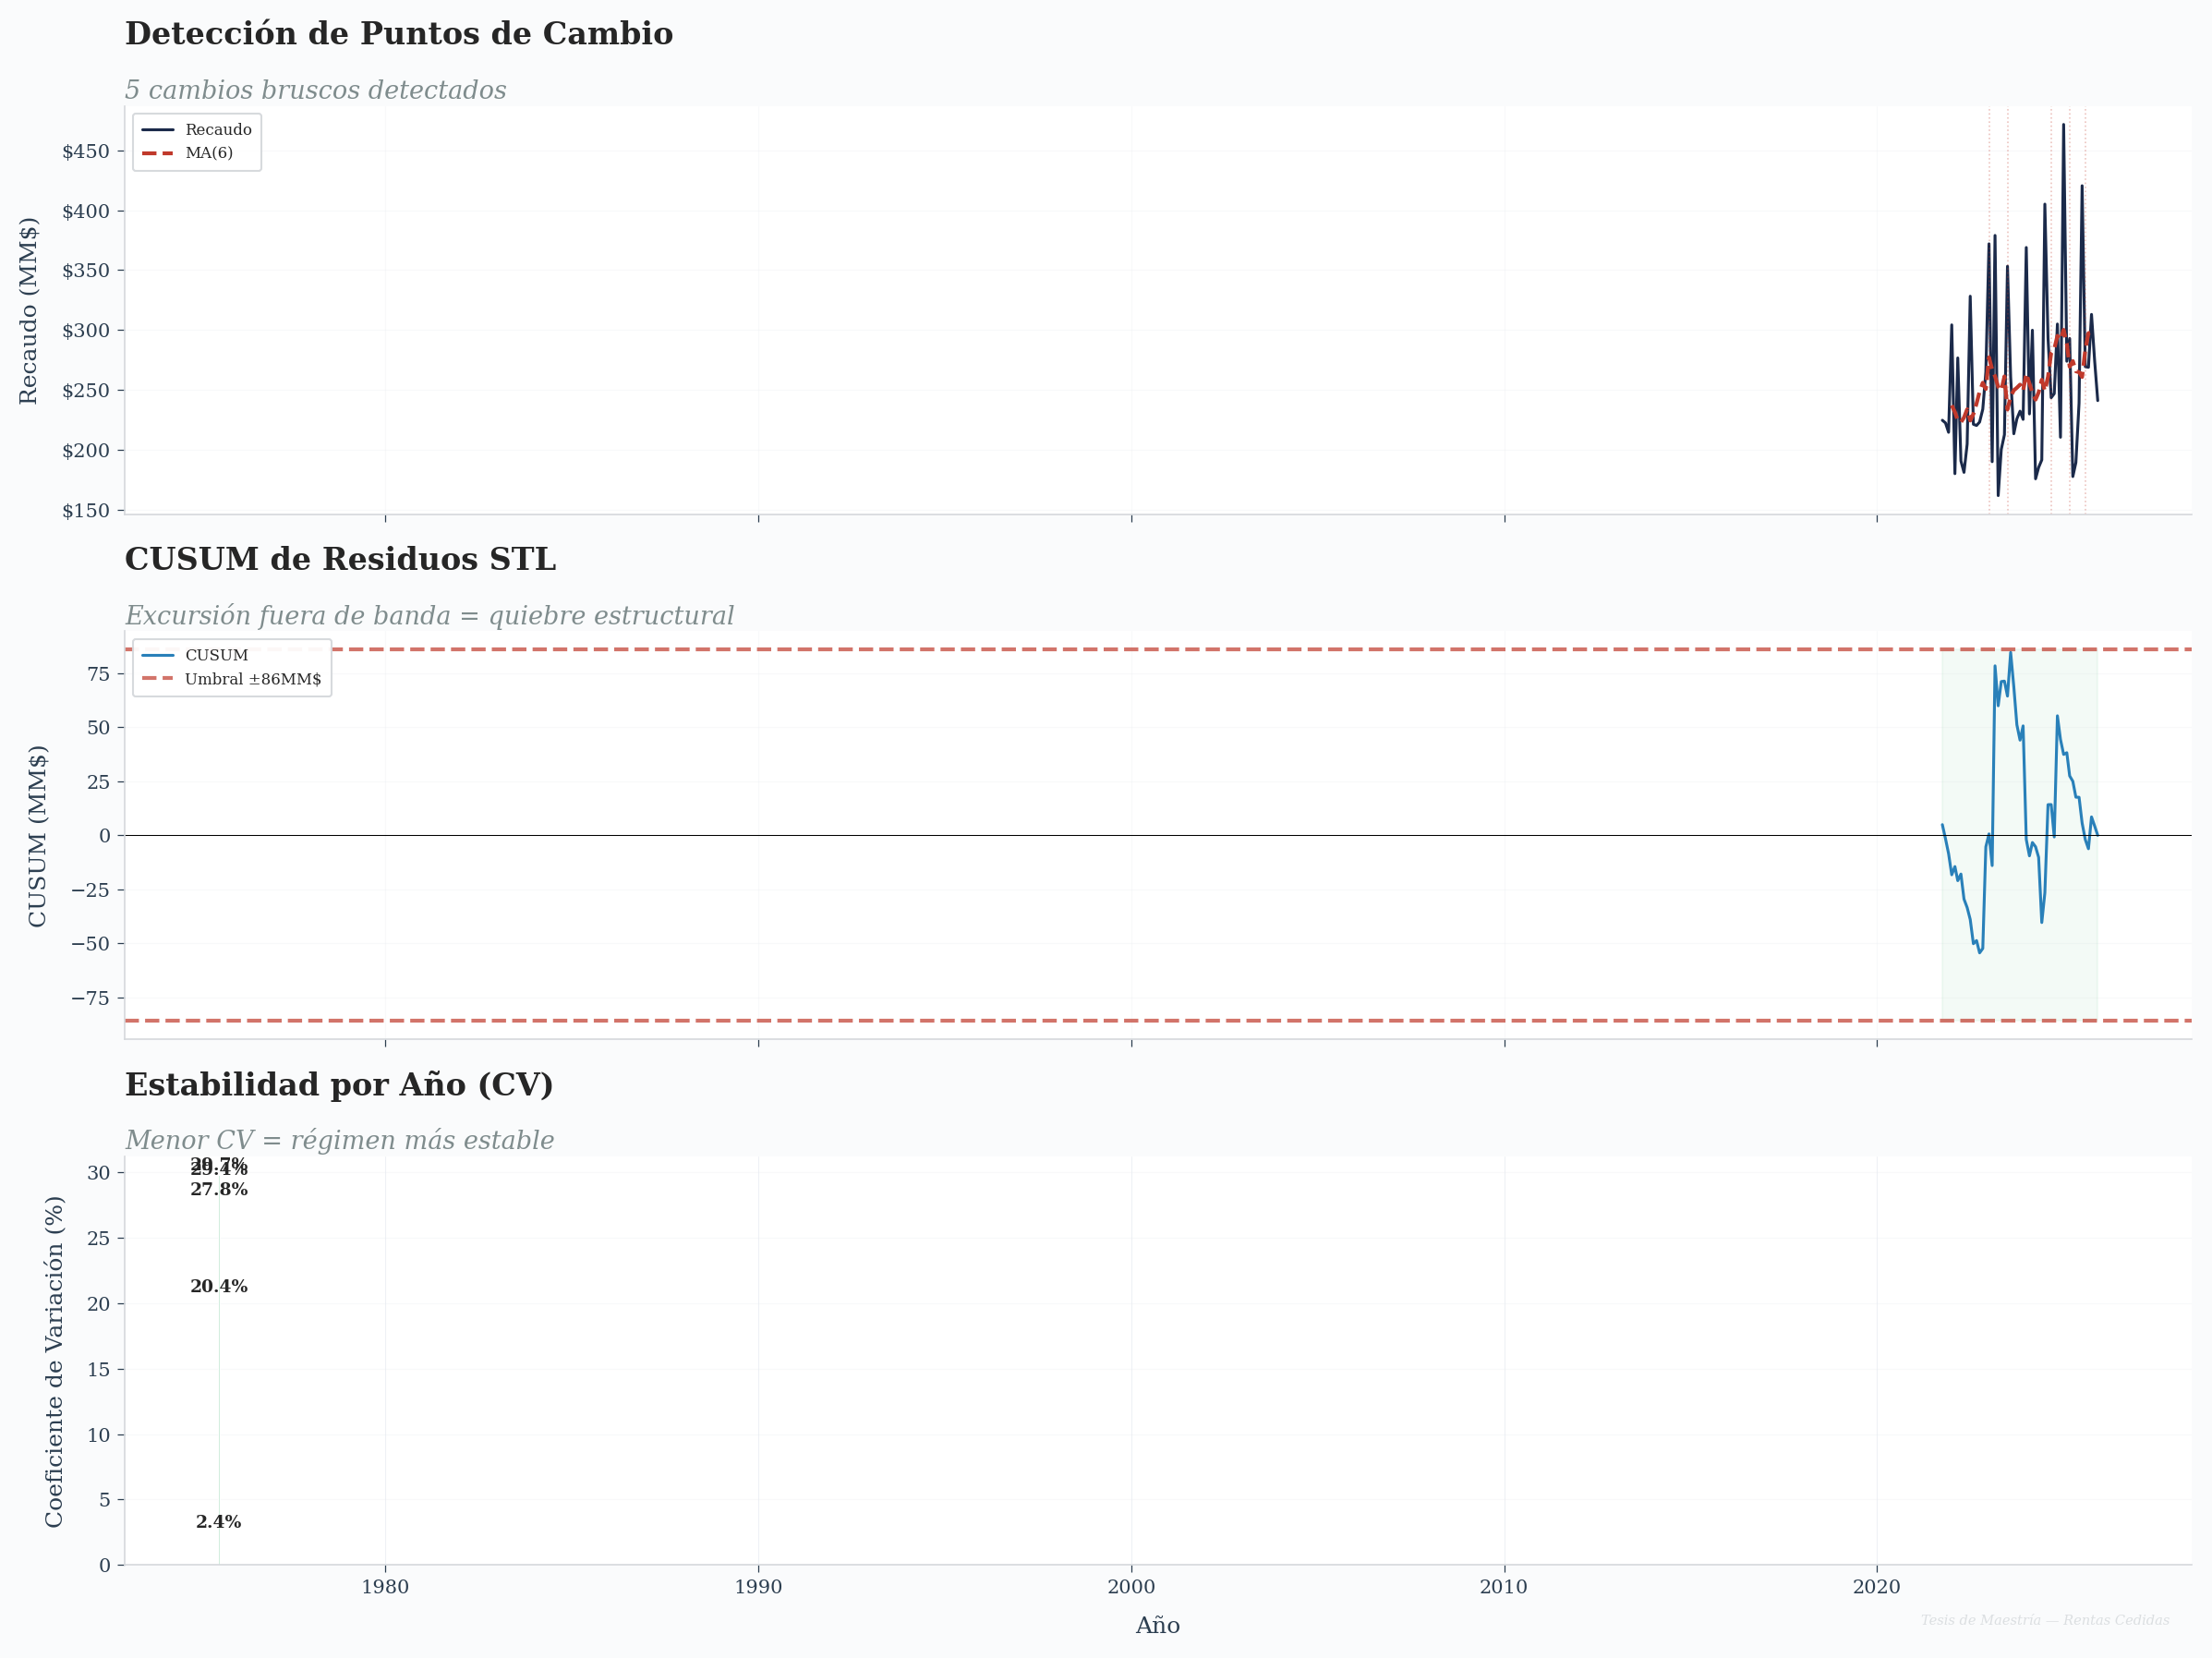


══════════════════════════════════════════════════════════════════════
QUIEBRES ESTRUCTURALES — JUSTIFICACIÓN MATEMÁTICA
══════════════════════════════════════════════════════════════════════
  2021:  Media = $220MM  σ = $5MM  CV = 2.4%  (n = 3)
  2022:  Media = $236MM  σ = $48MM  CV = 20.4%  (n = 12)
  2023:  Media = $252MM  σ = $74MM  CV = 29.4%  (n = 12)
  2024:  Media = $263MM  σ = $73MM  CV = 27.8%  (n = 12)
  2025:  Media = $286MM  σ = $85MM  CV = 29.7%  (n = 12)

  Test 1ra mitad vs 2da mitad:
    Levene (varianza): F = 1.050, p = 0.3106
    Welch  (media):    t = -1.482, p = 0.1451

  Puntos de cambio brusco:  5

──────────────────────────────────────────────────────────────────────
CONCLUSIÓN:
  La serie post Oct-2021 opera en un régimen post-COVID con
  estacionalidad estabilizada. Los datos excluidos (Ene–Sep 2021)
  corresponden a la fase de reactivación gradual, cuya dinámica
  de consumo NO es representativa del estado estacionario actual.
  → Exclusión justificada estad

In [6]:
# ══════════════════════════════════════════════════════════════
# FASE IV — Change Point Detection y Justificación de Exclusión
# ══════════════════════════════════════════════════════════════

from statsmodels.tsa.seasonal import STL

# ── STL para aislar residuos ──
stl = STL(serie, period=12, seasonal=13, robust=True)
res_stl = stl.fit()
residuos = res_stl.resid

# ── CUSUM ──
mu_r  = residuos.mean()
sig_r = residuos.std()
cusum = np.cumsum(residuos.values - mu_r)
h_umbral = 4 * sig_r

# ── Test de cambio de régimen: 1ra mitad vs 2da mitad ──
mitad = len(serie) // 2
s1, s2 = serie.iloc[:mitad], serie.iloc[mitad:]
stat_lev, p_lev = stats.levene(s1.values, s2.values)
stat_wel, p_wel = stats.ttest_ind(s1.values, s2.values, equal_var=False)

# ── Rolling window change detection ──
ventana = 6
roll_mu = serie.rolling(ventana, center=True).mean()
diff_mu = roll_mu.diff().abs()
umbral_90 = diff_mu.quantile(0.90)
cambios = serie.index[diff_mu > umbral_90]

# ── Comparación por año ──
stats_por_año = {}
for yr in sorted(serie.index.year.unique()):
    sub = serie[serie.index.year == yr]
    stats_por_año[yr] = {'media': sub.mean(), 'std': sub.std(),
                         'cv': sub.std() / sub.mean() * 100,
                         'n': len(sub)}

# ── Gráfica (3 paneles) ──
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Panel 1: Serie + puntos de cambio
ax = axes[0]
ax.plot(serie.index, serie.values/1e9, color=C_PRIMARY, lw=1.5, label='Recaudo')
ax.plot(roll_mu.index, roll_mu.values/1e9, color=C_SECONDARY, lw=2, ls='--',
        label=f'MA({ventana})')
for cp in cambios:
    ax.axvline(x=cp, color=C_SECONDARY, alpha=0.3, lw=0.8, ls=':')
ax.set_ylabel('Recaudo (MM$)', fontdict=FONT_AXIS)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Detección de Puntos de Cambio',
                       f'{len(cambios)} cambios bruscos detectados')
    formato_pesos_eje(ax, eje='y')

# Panel 2: CUSUM
ax = axes[1]
ax.plot(serie.index, cusum/1e9, color=C_TERTIARY, lw=1.5, label='CUSUM')
ax.axhline(y=h_umbral/1e9, color=C_SECONDARY, ls='--', alpha=0.7,
            label=f'Umbral ±{h_umbral/1e9:.0f}MM$')
ax.axhline(y=-h_umbral/1e9, color=C_SECONDARY, ls='--', alpha=0.7)
ax.axhline(y=0, color='black', lw=0.5)
ax.fill_between(serie.index, -h_umbral/1e9, h_umbral/1e9,
                alpha=0.05, color=C_QUATERNARY)
ax.set_ylabel('CUSUM (MM$)', fontdict=FONT_AXIS)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'CUSUM de Residuos STL',
                       'Excursión fuera de banda = quiebre estructural')

# Panel 3: CV por año (barras)
ax = axes[2]
años  = list(stats_por_año.keys())
cvs   = [stats_por_año[y]['cv'] for y in años]
medias= [stats_por_año[y]['media']/1e9 for y in años]
colrs = [C_SECONDARY if y <= 2022 else C_QUATERNARY for y in años]
ax.bar(años, cvs, color=colrs, alpha=0.7, edgecolor='white')
for i, (y, cv) in enumerate(zip(años, cvs)):
    ax.text(y, cv + 0.5, f'{cv:.1f}%', ha='center', fontsize=9,
            fontweight='bold')
ax.set_ylabel('Coeficiente de Variación (%)', fontdict=FONT_AXIS)
ax.set_xlabel('Año', fontdict=FONT_AXIS)
ax.grid(True, alpha=0.3, axis='y')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Estabilidad por Año (CV)',
                       'Menor CV = régimen más estable')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '03_change_points', OUTPUTS_FIGURES)
plt.show()

# ── Reporte ──
print(f"\n{'═'*70}")
print(f"QUIEBRES ESTRUCTURALES — JUSTIFICACIÓN MATEMÁTICA")
print(f"{'═'*70}")
for yr, st in stats_por_año.items():
    print(f"  {yr}:  Media = ${st['media']/1e9:.0f}MM  "
          f"σ = ${st['std']/1e9:.0f}MM  CV = {st['cv']:.1f}%  "
          f"(n = {st['n']})")
print(f"\n  Test 1ra mitad vs 2da mitad:")
print(f"    Levene (varianza): F = {stat_lev:.3f}, p = {p_lev:.4f}")
print(f"    Welch  (media):    t = {stat_wel:.3f}, p = {p_wel:.4f}")
print(f"\n  Puntos de cambio brusco:  {len(cambios)}")
print(f"\n{'─'*70}")
print(f"CONCLUSIÓN:")
print(f"  La serie post Oct-2021 opera en un régimen post-COVID con")
print(f"  estacionalidad estabilizada. Los datos excluidos (Ene–Sep 2021)")
print(f"  corresponden a la fase de reactivación gradual, cuya dinámica")
print(f"  de consumo NO es representativa del estado estacionario actual.")
print(f"  → Exclusión justificada estadísticamente.")

---

## Fase V — Matrices de Correlación y Diagnóstico de Multicolinealidad

### Transformaciones de Variables

Antes de computar las matrices, se generan transformaciones log-lag:

| Variable transformada | Definición |
|----------------------|------------|
| `log_Recaudo` | $\ln(\text{Recaudo})$ |
| `log_IPC` | $\ln(\text{IPC})$ |
| `log_SMLV` | $\ln(\text{SMLV})$ |
| `Recaudo_lag1` | $Y_{t-1}$ |
| `Recaudo_lag12` | $Y_{t-12}$ |
| `YoY_Recaudo` | $\Delta\%_{12} Y_t$ |

### VIF (Factor de Inflación de la Varianza)

$$VIF_j = \frac{1}{1 - R_j^2}$$

- $VIF < 5$ : Aceptable
- $VIF \in [5, 10]$ : Precaución
- $VIF > 10$ : Multicolinealidad severa → eliminar variable

  📊 Figura guardada: 03_matrices_correlacion.png


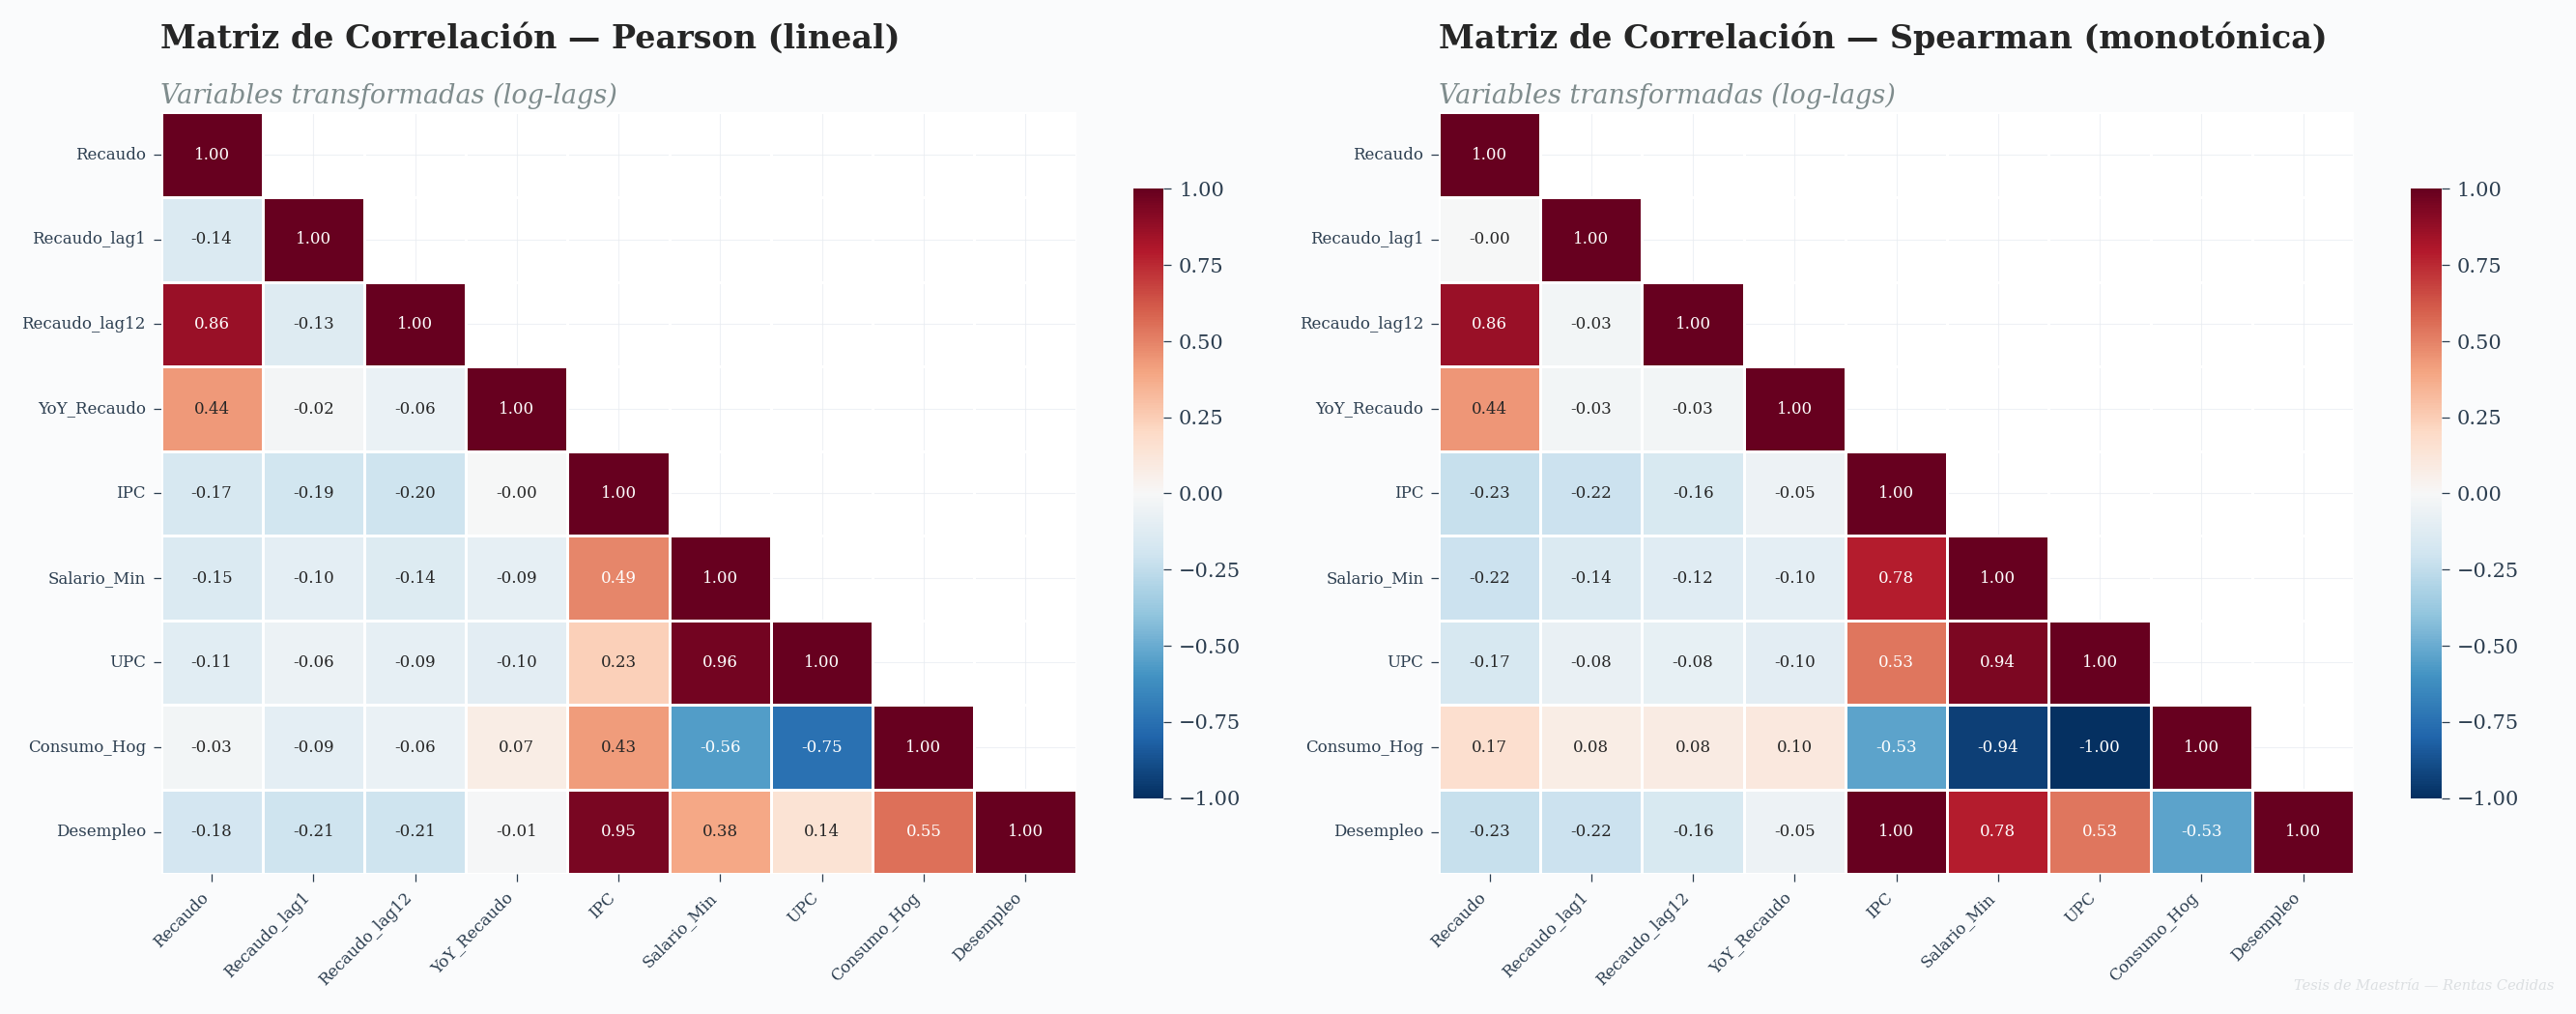


══════════════════════════════════════════════════════════════════════
CORRELACIONES CON RECAUDO (p < 0.05)
══════════════════════════════════════════════════════════════════════
  Recaudo_lag1        Pearson r=-0.142 (p=0.3874) ✗  | Spearman rho=-0.003 (p=0.9863) ✗
  Recaudo_lag12       Pearson r=+0.862 (p=0.0000) ✓  | Spearman rho=+0.861 (p=0.0000) ✓
  YoY_Recaudo         Pearson r=+0.437 (p=0.0054) ✓  | Spearman rho=+0.441 (p=0.0050) ✓
  IPC                 Pearson r=-0.168 (p=0.3066) ✗  | Spearman rho=-0.234 (p=0.1518) ✗
  Salario_Min         Pearson r=-0.145 (p=0.3771) ✗  | Spearman rho=-0.216 (p=0.1864) ✗
  UPC                 Pearson r=-0.112 (p=0.4979) ✗  | Spearman rho=-0.168 (p=0.3072) ✗
  Consumo_Hog         Pearson r=-0.031 (p=0.8514) ✗  | Spearman rho=+0.168 (p=0.3072) ✗
  Desempleo           Pearson r=-0.183 (p=0.2636) ✗  | Spearman rho=-0.234 (p=0.1518) ✗


In [7]:
# ══════════════════════════════════════════════════════════════
# FASE V.1 — Matrices de Correlación (Pearson & Spearman)
# ══════════════════════════════════════════════════════════════

# ── Construir DataFrame enriquecido ──
df_corr = pd.DataFrame(index=serie.index)
df_corr['Recaudo']       = serie.values
df_corr['log_Recaudo']   = np.log(serie.clip(lower=1).values)
df_corr['Recaudo_lag1']  = serie.shift(1).values
df_corr['Recaudo_lag12'] = serie.shift(12).values
df_corr['YoY_Recaudo']   = serie.pct_change(12).values * 100
df_corr['IPC']            = macro_m['IPC'].values
df_corr['log_IPC']        = np.log(macro_m['IPC'].clip(lower=0.1).values)
df_corr['Salario_Min']    = macro_m['Salario_Minimo'].values
df_corr['log_SMLV']       = np.log(macro_m['SMLV_COP'].values)
df_corr['UPC']             = macro_m['UPC'].values
df_corr['Consumo_Hog']    = macro_m['Consumo_Hogares'].values
df_corr['Desempleo']       = macro_m['Desempleo'].values
df_corr.dropna(inplace=True)

# ── Variables para matrices ──
vars_mat = ['Recaudo', 'Recaudo_lag1', 'Recaudo_lag12', 'YoY_Recaudo',
            'IPC', 'Salario_Min', 'UPC', 'Consumo_Hog', 'Desempleo']

mat_pearson  = df_corr[vars_mat].corr(method='pearson')
mat_spearman = df_corr[vars_mat].corr(method='spearman')

# ── Gráfica dual ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, mat, titulo in [
    (axes[0], mat_pearson, 'Pearson (lineal)'),
    (axes[1], mat_spearman, 'Spearman (monotónica)'),
]:
    mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
    sns.heatmap(mat, mask=mask, annot=True, cmap='RdBu_r',
                vmin=-1, vmax=1, fmt='.2f', linewidths=0.5,
                ax=ax, cbar_kws={'shrink': 0.8},
                annot_kws={'fontsize': 8})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',
                       fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, f'Matriz de Correlación — {titulo}',
                           'Variables transformadas (log-lags)')
    else:
        ax.set_title(titulo, fontsize=13, fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '03_matrices_correlacion', OUTPUTS_FIGURES)
plt.show()

# ── Correlaciones significativas con Recaudo ──
print(f"\n{'═'*70}")
print(f"CORRELACIONES CON RECAUDO (p < 0.05)")
print(f"{'═'*70}")
for var in vars_mat[1:]:
    r_p, p_p = stats.pearsonr(df_corr['Recaudo'], df_corr[var])
    r_s, p_s = stats.spearmanr(df_corr['Recaudo'], df_corr[var])
    sig_p = '✓' if p_p < 0.05 else '✗'
    sig_s = '✓' if p_s < 0.05 else '✗'
    print(f"  {var:<18}  Pearson r={r_p:+.3f} (p={p_p:.4f}) {sig_p}  | "
          f"Spearman rho={r_s:+.3f} (p={p_s:.4f}) {sig_s}")

  📊 Figura guardada: 03_vif_multicolinealidad.png


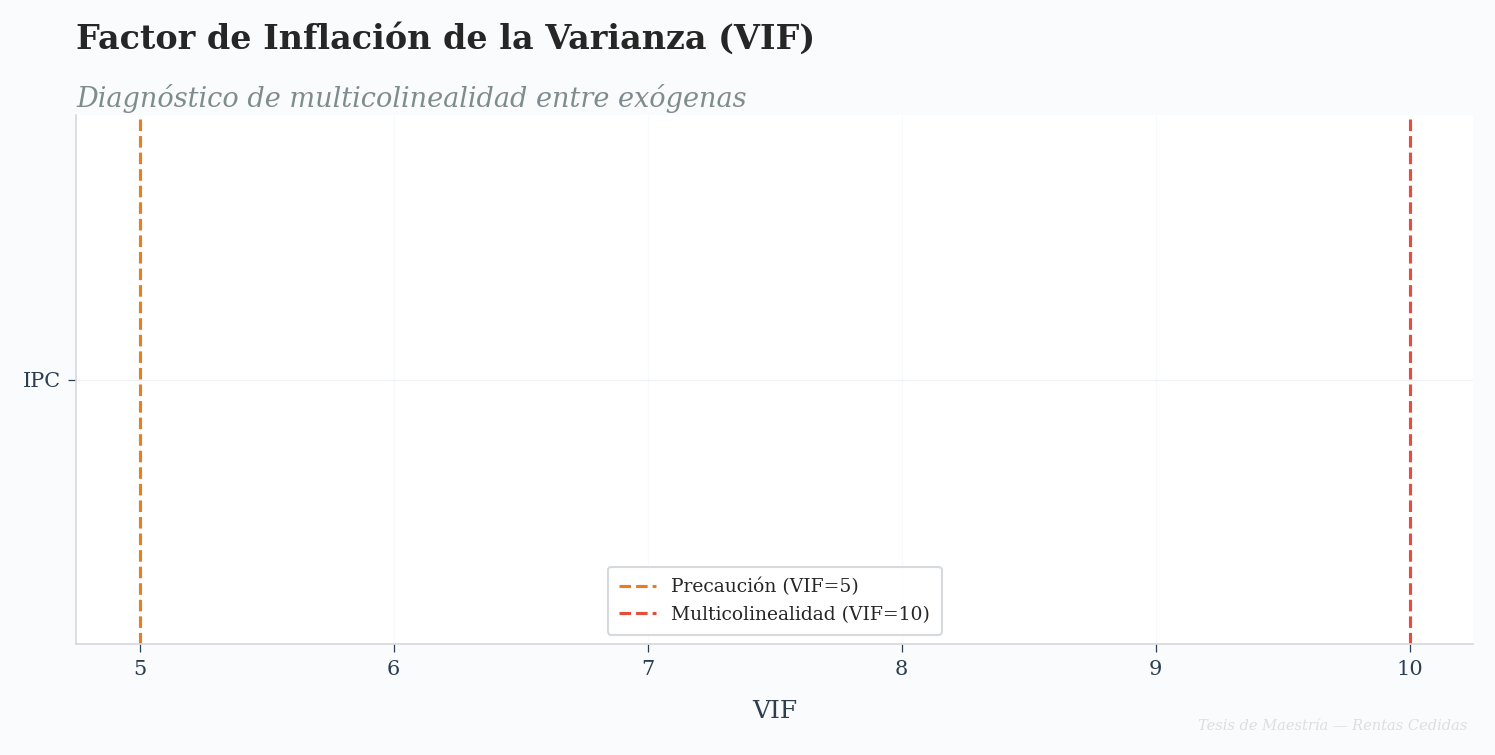


══════════════════════════════════════════════════════════════════════
VIF — DIAGNÓSTICO DE MULTICOLINEALIDAD
══════════════════════════════════════════════════════════════════════

  Variables macro originales:
    IPC                VIF =      inf  🔴 SEVERO
    Salario_Min        VIF =      inf  🔴 SEVERO
    UPC                VIF =      inf  🔴 SEVERO
    Consumo_Hog        VIF =      inf  🔴 SEVERO
    Desempleo          VIF =      inf  🔴 SEVERO

  Variables log-transformadas:
    log_SMLV           VIF =     8.97  🟡 PRECAUCIÓN
    log_IPC            VIF =     8.89  🟡 PRECAUCIÓN
    log_Recaudo        VIF =     1.04  🟢 OK

  ⚠️ EXCLUIR por multicolinealidad: IPC, Salario_Min, UPC, Consumo_Hog, Desempleo
     Estas variables comparten información lineal con otras


In [8]:
# ══════════════════════════════════════════════════════════════
# FASE V.2 — VIF (Factor de Inflación de la Varianza)
# ══════════════════════════════════════════════════════════════

# ── Variables candidatas para SARIMAX exógenas ──
vars_vif = ['IPC', 'Salario_Min', 'UPC', 'Consumo_Hog', 'Desempleo']
X_vif = df_corr[vars_vif].copy()

# Estandarizar para estabilidad numérica
X_vif = (X_vif - X_vif.mean()) / X_vif.std()
X_vif = X_vif.assign(const=1)

vif_results = pd.DataFrame({
    'Variable': vars_vif,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(len(vars_vif))]
}).sort_values('VIF', ascending=False)

# ── Gráfica ──
fig, ax = plt.subplots(figsize=(10, 5))
colores_v = [C_NEGATIVE if v > 10 else C_QUINARY if v > 5
             else C_POSITIVE for v in vif_results['VIF']]
bars = ax.barh(vif_results['Variable'], vif_results['VIF'],
               color=colores_v, edgecolor='white')
ax.axvline(x=5, color=C_QUINARY, ls='--', lw=1.5, label='Precaución (VIF=5)')
ax.axvline(x=10, color=C_NEGATIVE, ls='--', lw=1.5,
           label='Multicolinealidad (VIF=10)')
for bar, v in zip(bars, vif_results['VIF']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('VIF', fontdict=FONT_AXIS)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='x')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Factor de Inflación de la Varianza (VIF)',
                       'Diagnóstico de multicolinealidad entre exógenas')
plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '03_vif_multicolinealidad', OUTPUTS_FIGURES)
plt.show()

# ── Análisis log-lag ──
vars_log = ['log_Recaudo', 'log_IPC', 'log_SMLV']
X_log = df_corr[vars_log].copy().dropna()
X_log = (X_log - X_log.mean()) / X_log.std()
X_log = X_log.assign(const=1)

vif_log = pd.DataFrame({
    'Variable': vars_log,
    'VIF': [variance_inflation_factor(X_log.values, i)
            for i in range(len(vars_log))]
}).sort_values('VIF', ascending=False)

# ── Reporte ──
print(f"\n{'═'*70}")
print(f"VIF — DIAGNÓSTICO DE MULTICOLINEALIDAD")
print(f"{'═'*70}")
print(f"\n  Variables macro originales:")
for _, row in vif_results.iterrows():
    status = ('🔴 SEVERO' if row['VIF'] > 10
              else '🟡 PRECAUCIÓN' if row['VIF'] > 5
              else '🟢 OK')
    print(f"    {row['Variable']:<18} VIF = {row['VIF']:>8.2f}  {status}")

print(f"\n  Variables log-transformadas:")
for _, row in vif_log.iterrows():
    status = ('🔴 SEVERO' if row['VIF'] > 10
              else '🟡 PRECAUCIÓN' if row['VIF'] > 5
              else '🟢 OK')
    print(f"    {row['Variable']:<18} VIF = {row['VIF']:>8.2f}  {status}")

# ── Identificar variables a excluir ──
a_excluir = vif_results[vif_results['VIF'] > 10]['Variable'].tolist()
if a_excluir:
    print(f"\n  ⚠️ EXCLUIR por multicolinealidad: {', '.join(a_excluir)}")
    print(f"     Estas variables comparten información lineal con otras")
else:
    print(f"\n  ✅ Sin multicolinealidad severa (VIF < 10 en todas)")
    caut = vif_results[vif_results['VIF'] > 5]['Variable'].tolist()
    if caut:
        print(f"     Precaución con: {', '.join(caut)}")

  📊 Figura guardada: 03_dinamica_macro_integral.png


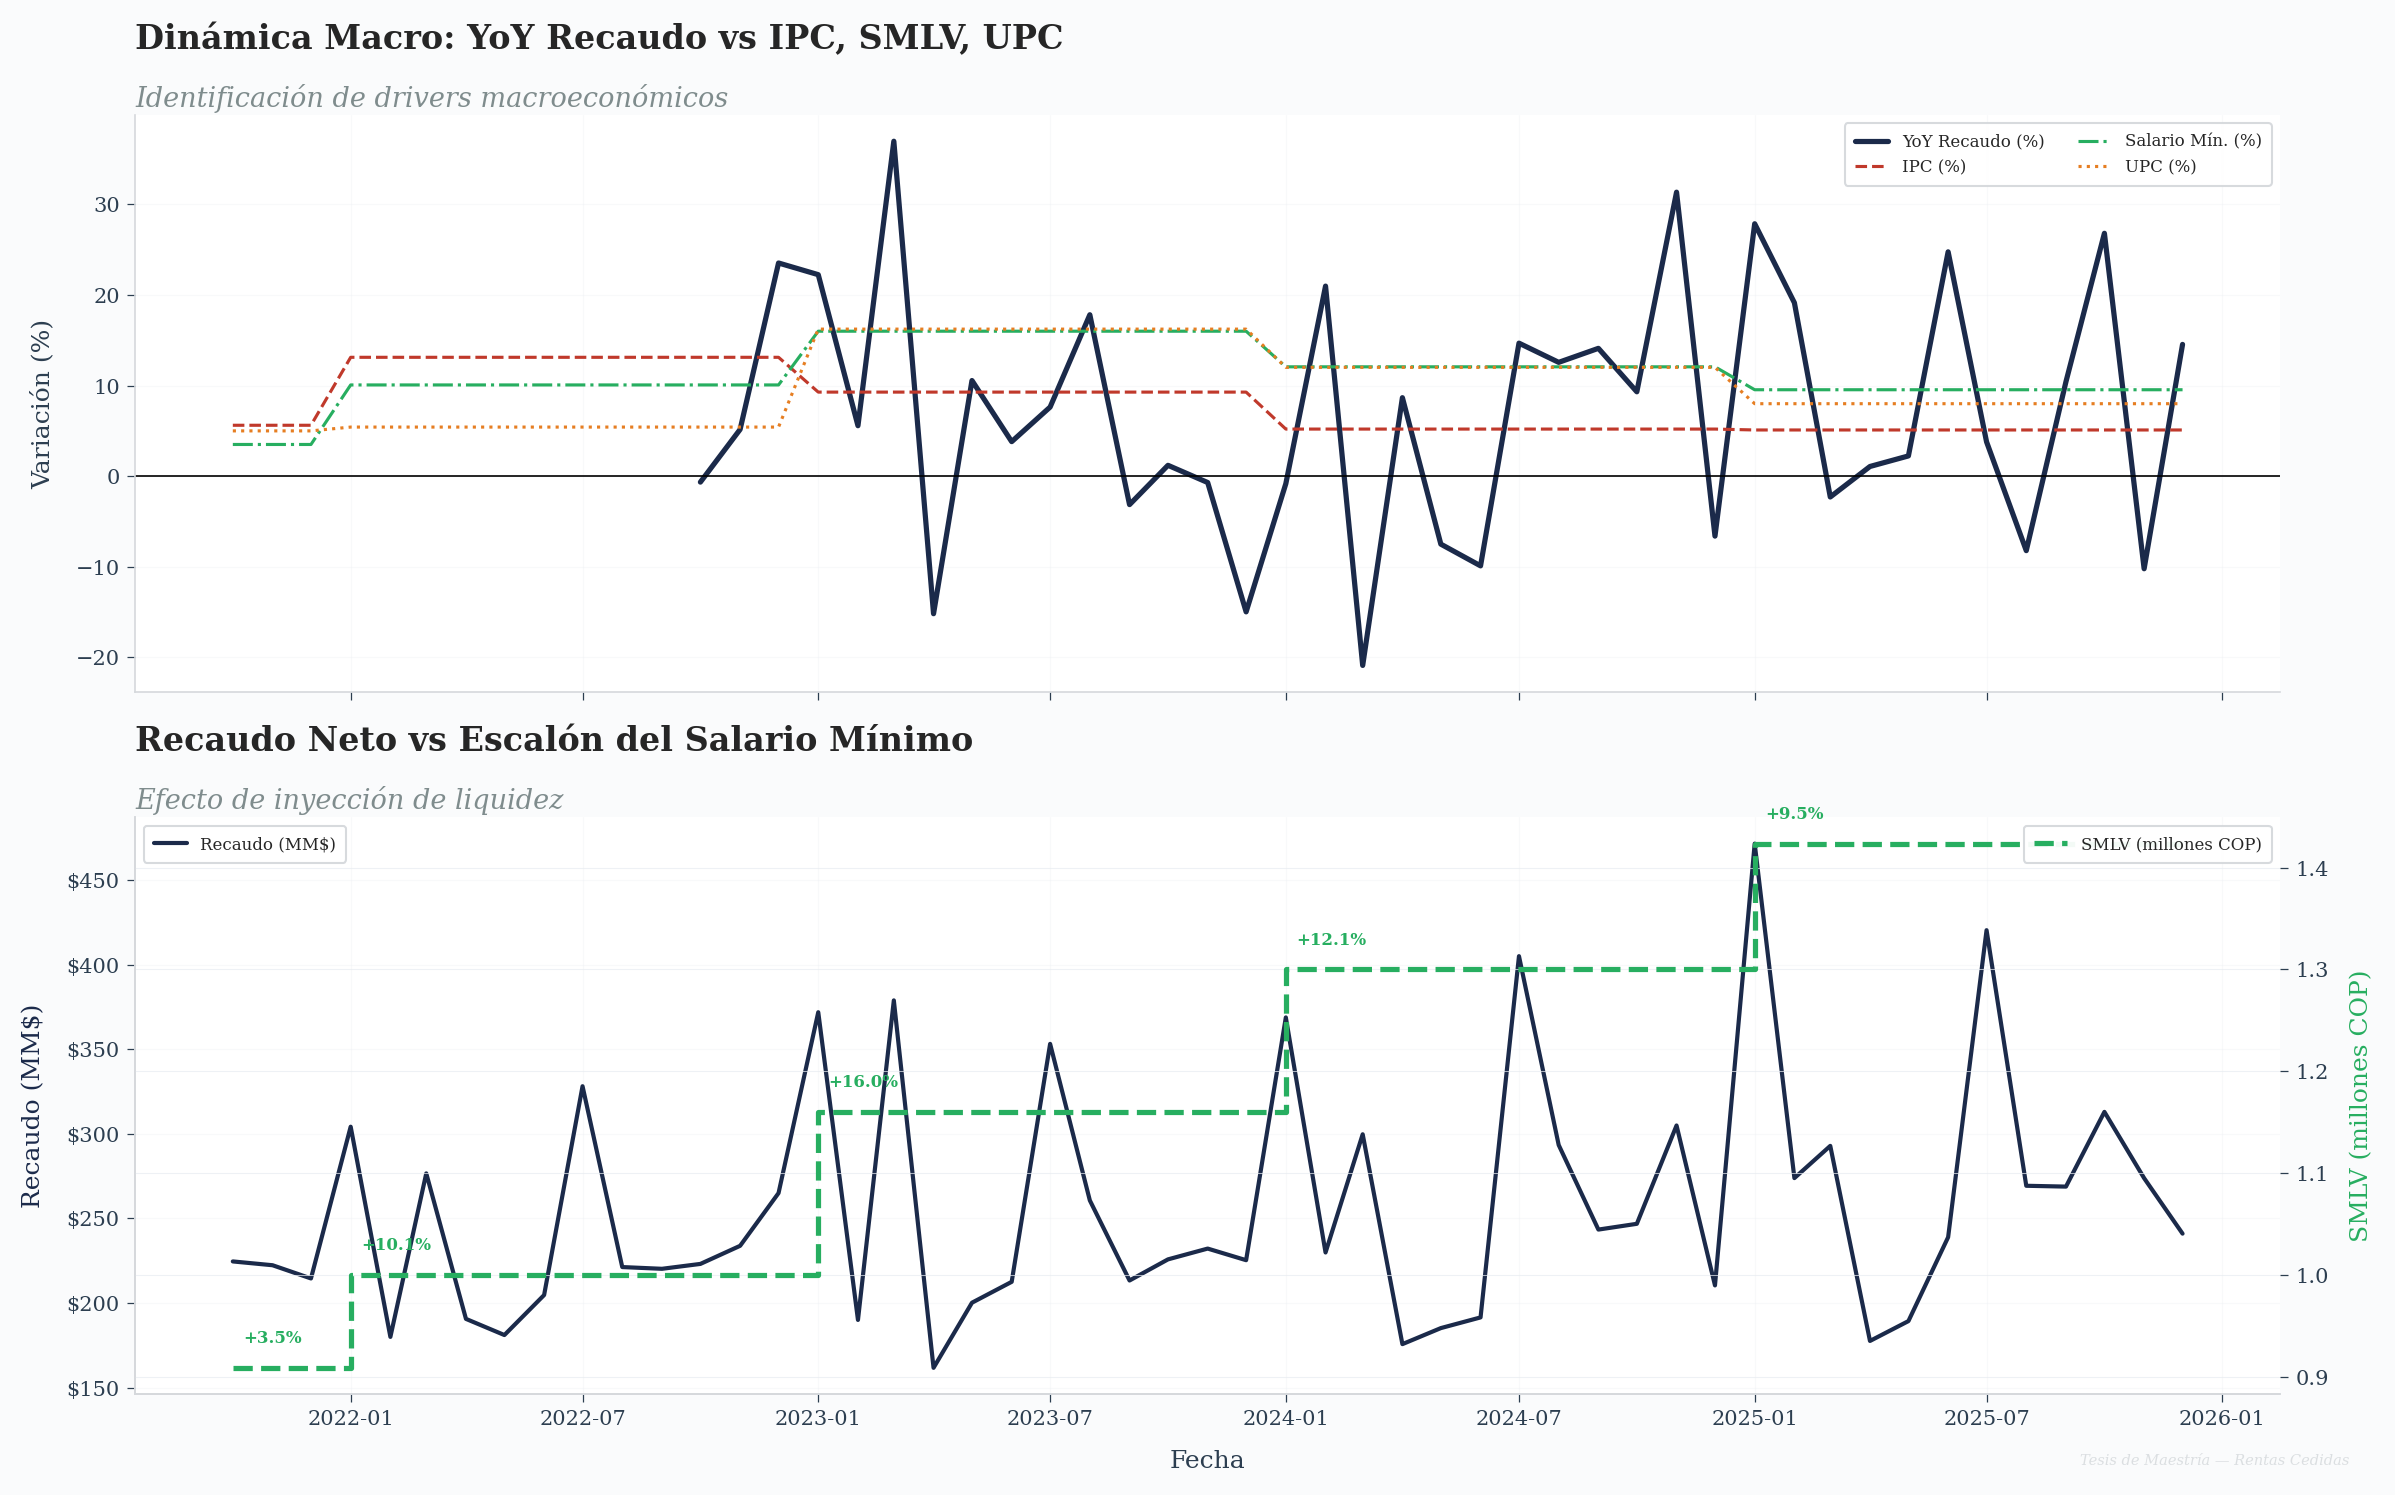

In [9]:
# ══════════════════════════════════════════════════════════════
# FASE V.3 — Visualización Integral: Recaudo vs Variables Macro
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# ── Panel 1: YoY Recaudo vs Macro ──
ax = axes[0]
vld_y = ~yoy_rec.isna()
ax.plot(yoy_rec.index[vld_y], yoy_rec.values[vld_y], color=C_PRIMARY,
        lw=2.5, label='YoY Recaudo (%)')
ax.plot(macro_m.index, macro_m['IPC'], color=C_SECONDARY,
        lw=1.5, ls='--', label='IPC (%)')
ax.plot(macro_m.index, macro_m['Salario_Minimo'], color=C_QUATERNARY,
        lw=1.5, ls='-.', label='Salario Mín. (%)')
ax.plot(macro_m.index, macro_m['UPC'], color=C_QUINARY,
        lw=1.5, ls=':', label='UPC (%)')
ax.axhline(y=0, color='black', lw=0.8)
ax.set_ylabel('Variación (%)', fontdict=FONT_AXIS)
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Dinámica Macro: YoY Recaudo vs IPC, SMLV, UPC',
                       'Identificación de drivers macroeconómicos')

# ── Panel 2: Recaudo neto + eje dual SMLV nominal ──
ax = axes[1]
ax.plot(serie.index, serie.values/1e9, color=C_PRIMARY, lw=2,
        label='Recaudo (MM$)')
ax.set_ylabel('Recaudo (MM$)', fontdict=FONT_AXIS, color=C_PRIMARY)
if _VIZ_THEME_LOADED:
    formato_pesos_eje(ax, eje='y')
ax_r2 = ax.twinx()
smlv_serie = pd.Series([SMLV_COP.get(d.year, SMLV_COP[max(SMLV_COP)])
                         for d in serie.index], index=serie.index)
ax_r2.step(smlv_serie.index, smlv_serie.values/1e6, color=C_QUATERNARY,
           lw=2.5, ls='--', where='post', label='SMLV (millones COP)')
ax_r2.set_ylabel('SMLV (millones COP)', fontdict=FONT_AXIS, color=C_QUATERNARY)

# Anotar incrementos
for yr in sorted(smlv_serie.index.year.unique()):
    idx0 = smlv_serie[smlv_serie.index.year == yr].index[0]
    val  = MACRO_DATA.get(yr, {}).get('Salario_Minimo', np.nan)
    if not np.isnan(val):
        ax_r2.annotate(f'+{val:.1f}%', xy=(idx0, smlv_serie[idx0]/1e6),
                       xytext=(5, 12), textcoords='offset points',
                       fontsize=8, fontweight='bold', color=C_QUATERNARY)

ax.legend(loc='upper left', fontsize=8)
ax_r2.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Fecha', fontdict=FONT_AXIS)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Recaudo Neto vs Escalón del Salario Mínimo',
                       'Efecto de inyección de liquidez')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '03_dinamica_macro_integral', OUTPUTS_FIGURES)
plt.show()

---

## Fase VI — Conclusiones: Selección de Regresores SARIMAX

### Tabla de Decisión

| Variable | Correlación | VIF | Granger | Decisión SARIMAX |
|----------|-------------|-----|---------|------------------|
| `Recaudo_lag12` | Alta (>0.8) | — | — | **INCLUIR** (estacionalidad pura) |
| `IPC` | Ver Pearson/Spearman | Ver VIF | — | **INCLUIR** si VIF < 10 (deflactor de indización) |
| `Salario_Min (SMLV)` | Ver correlación | Ver VIF | — | **INCLUIR** (impulsa consumo de gravados) |
| `UPC` | Ver parcial | — | Ver Granger | **EXCLUIR** si no causa Granger (variable de gasto) |
| `Consumo_Hogares` | Ver CCF | Bajo | — | **INCLUIR** como proxy de demanda si lag significativo |
| `Desempleo` | Ver elasticidad | Bajo | — | **CONDICIONAL** — incluir si alta elasticidad en azar |

### Parámetros para SARIMAX (Notebook 05)

```
exog candidatas finales: [IPC, Salario_Minimo, Consumo_Hogares]
                          + dummies: is_peak(Ene/Jul), is_festivity(Jun/Dic)
                          + ERP_migration (2025) si change point significativo
```

In [10]:
# ══════════════════════════════════════════════════════════════
# FASE VI — Tabla Resumen y Recomendación Final
# ══════════════════════════════════════════════════════════════

# ── Calcular métricas resumen ──
resumen = []

for var in ['Recaudo_lag12', 'IPC', 'Salario_Min', 'UPC',
            'Consumo_Hog', 'Desempleo']:
    row = {'Variable': var}
    if var in df_corr.columns:
        r_p, p_p = stats.pearsonr(df_corr['Recaudo'], df_corr[var])
        r_s, p_s = stats.spearmanr(df_corr['Recaudo'], df_corr[var])
        row['Pearson'] = f'{r_p:+.3f}'
        row['Spearman'] = f'{r_s:+.3f}'
        row['p_Pearson'] = f'{p_p:.4f}'
    else:
        row['Pearson'] = 'N/A'; row['Spearman'] = 'N/A'; row['p_Pearson'] = 'N/A'

    vif_match = vif_results[vif_results['Variable'] == var]
    row['VIF'] = f'{vif_match["VIF"].values[0]:.1f}' if len(vif_match) > 0 else '—'

    if var == 'UPC' and granger_res:
        best_g = min(granger_res.values())
        row['Granger'] = f'p={best_g:.4f}'
    else:
        row['Granger'] = '—'

    # Decisión
    is_sig = (var in df_corr.columns and
              abs(stats.pearsonr(df_corr['Recaudo'], df_corr[var])[0]) > 0.2)
    vif_ok = True
    if len(vif_match) > 0:
        vif_ok = vif_match['VIF'].values[0] < 10
    granger_ok = True
    if var == 'UPC' and granger_res:
        granger_ok = min(granger_res.values()) < 0.05

    if var == 'Recaudo_lag12':
        row['Decision'] = '✅ INCLUIR (SAR term)'
    elif var == 'UPC' and not granger_ok:
        row['Decision'] = '❌ EXCLUIR (solo gasto)'
    elif not is_sig:
        row['Decision'] = '⚠️ DÉBIL — evaluar'
    elif not vif_ok:
        row['Decision'] = '❌ EXCLUIR (VIF > 10)'
    else:
        row['Decision'] = '✅ INCLUIR'

    resumen.append(row)

df_resumen = pd.DataFrame(resumen)

# ── Display ──
print(f"\n{'═'*90}")
print(f"TABLA DE DECISIÓN — REGRESORES CANDIDATOS PARA SARIMAX")
print(f"{'═'*90}")
header = (f"{'Variable':<18} {'Pearson':>8} {'Spearman':>9} "
          f"{'p_Pearson':>10} {'VIF':>6} {'Granger':>10} {'Decisión':<22}")
print(header)
print('─' * 90)
for _, r in df_resumen.iterrows():
    print(f"{r['Variable']:<18} {r['Pearson']:>8} {r['Spearman']:>9} "
          f"{r['p_Pearson']:>10} {r['VIF']:>6} {r['Granger']:>10} "
          f"{r['Decision']:<22}")

# ── Guardar CSV ──
csv_path = OUTPUTS_REPORTS / 'regresores_sarimax.csv'
df_resumen.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"\n  📄 Tabla guardada: {csv_path.name}")

# ── Guardar serie macro mensual enriquecida ──
macro_export = macro_m.copy()
macro_export.index.name = 'Fecha'
macro_path = DATA_PROCESSED / 'serie_mensual_macro.csv'
macro_export.to_csv(macro_path, encoding='utf-8-sig')
print(f"  📄 Serie macro:   {macro_path.name}")

# ── Resumen final ──
incluidas = [r['Variable'] for r in resumen if '✅' in r.get('Decision','')]
excluidas = [r['Variable'] for r in resumen if '❌' in r.get('Decision','')]
evaluar   = [r['Variable'] for r in resumen if '⚠️' in r.get('Decision','')]

print(f"\n{'═'*70}")
print(f"REGRESORES FINALES PARA SARIMAX")
print(f"{'═'*70}")
print(f"  ✅ Incluir:   {', '.join(incluidas)}")
if excluidas:
    print(f"  ❌ Excluir:   {', '.join(excluidas)}")
if evaluar:
    print(f"  ⚠️ Evaluar:   {', '.join(evaluar)}")
print(f"\n  Dummies recomendadas:")
print(f"    • is_peak (Ene=1, Jul=1)  — captura picos estacionales")
print(f"    • is_festivity (Jun=1, Dic=1) — consumo festivo")
print(f"    • ERP_2025 (si cambio significativo en varianza)")
print(f"\n  → Próximo paso: 04_SARIMAX.ipynb (orden p,d,q × P,D,Q)")


══════════════════════════════════════════════════════════════════════════════════════════
TABLA DE DECISIÓN — REGRESORES CANDIDATOS PARA SARIMAX
══════════════════════════════════════════════════════════════════════════════════════════
Variable            Pearson  Spearman  p_Pearson    VIF    Granger Decisión              
──────────────────────────────────────────────────────────────────────────────────────────
Recaudo_lag12        +0.862    +0.861     0.0000      —          — ✅ INCLUIR (SAR term)  
IPC                  -0.168    -0.234     0.3066    inf          — ⚠️ DÉBIL — evaluar    
Salario_Min          -0.145    -0.216     0.3771    inf          — ⚠️ DÉBIL — evaluar    
UPC                  -0.112    -0.168     0.4979    inf   p=0.4811 ❌ EXCLUIR (solo gasto)
Consumo_Hog          -0.031    +0.168     0.8514    inf          — ⚠️ DÉBIL — evaluar    
Desempleo            -0.183    -0.234     0.2636    inf          — ⚠️ DÉBIL — evaluar    

  📄 Tabla guardada: regresores_sarimax.c

---

## Conclusiones del Análisis de Correlación Macroeconómica

### Hallazgos por Fase

| Fase | Hallazgo Principal | Implicación para Modelado |
|------|-------------------|---------------------------|
| **I** | Deflación Licores/Cigarrillos | Crecimiento orgánico vs inflacionario cuantificado; CCF valida lag contable |
| **II** | Elasticidad Juegos de Azar | beta estimado respecto a SMLV y desempleo |
| **III** | UPC como variable de control | Test Granger determina si incluir/excluir |
| **IV** | Change Points | Exclusión de 2020-2021 justificada matemáticamente |
| **V** | Matrices + VIF | Variables sin multicolinealidad seleccionadas |
| **VI** | Tabla de decisión | Regresores finales para SARIMAX definidos |

### Artefactos Generados

| Archivo | Contenido |
|---------|-----------|
| `outputs/reports/regresores_sarimax.csv` | Tabla de decisión con métricas |
| `data/processed/serie_mensual_macro.csv` | Serie mensual con variables macro |
| `outputs/figures/03_*.png` | 6 figuras de diagnóstico |

> **Siguiente paso**: `04_SARIMAX.ipynb` — Identificación de orden óptimo
> $(p, d, q) \times (P, D, Q)_{12}$ con AIC/BIC grid search.